## Identifikasi Suara “Buka” dan “Tutup” Menggunakan Feature Statistik Time Series + KNN

### 1. Import Library
Menyiapkan semua library dan memastikan struktur dataset benar.

In [31]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import soundfile as sf
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

print(" Semua library berhasil diimport!")


 Semua library berhasil diimport!


### 2. Cek Struktur Folder Dataset

In [32]:
DATASET_PATH = "suara/"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files:
        print(f"{' ' * 2 * (level + 1)}🎵 {f}")
print(" Struktur folder dataset sudah benar.")

📁 /
📁 buka/
  🎵 buka92.wav
  🎵 buka54.wav
  🎵 buka75.wav
  🎵 buka10.wav
  🎵 buka53.wav
  🎵 buka86.wav
  🎵 buka105.wav
  🎵 buka65.wav
  🎵 buka87.wav
  🎵 buka64.wav
  🎵 buka61.wav
  🎵 buka14.wav
  🎵 buka96.wav
  🎵 buka104.wav
  🎵 buka59.wav
  🎵 buka13.wav
  🎵 buka48.wav
  🎵 buka 57.wav
  🎵 buka78.wav
  🎵 buka97.wav
  🎵 buka3.wav
  🎵 buka27.wav
  🎵 buka52.wav
  🎵 buka23.wav
  🎵 buka76.wav
  🎵 buka80.wav
  🎵 buka42.wav
  🎵 buka66.wav
  🎵 buka47.wav
  🎵 buka12.wav
  🎵 buka4.wav
  🎵 buka84.wav
  🎵 buka15.wav
  🎵 buka16.wav
  🎵 buka11.wav
  🎵 buka19.wav
  🎵 buka56.wav
  🎵 buka49.wav
  🎵 buka73.wav
  🎵 buka91.wav
  🎵 buka30.wav
  🎵 buka37.wav
  🎵 buka35.wav
  🎵 buka77.wav
  🎵 buka106.wav
  🎵 buka32.wav
  🎵 buka63.wav
  🎵 buka41.wav
  🎵 buka70.wav
  🎵 buka29.wav
  🎵 buka98.wav
  🎵 buka94.wav
  🎵 buka22.wav
  🎵 buka110.wav
  🎵 buka31.wav
  🎵 buka26.wav
  🎵 buka38.wav
  🎵 buka82.wav
  🎵 buka103.wav
  🎵 buka34.wav
  🎵 buka9.wav
  🎵 buka89.wav
  🎵 buka24.wav
  🎵 buka43.wav
  🎵 buka72.wav
  🎵 buka62

### 3. Eksplorasi Dataset Awal
Untuk mengetahui jumlah file, kelas (label), durasi, dan sample rate.

In [33]:
durations = []
DATASET_PATH = "suara/"

# Cek jumlah file per label
for label in os.listdir(DATASET_PATH):
    files = os.listdir(os.path.join(DATASET_PATH, label))
    print(f"Kelas {label}: {len(files)} file")
    
for label in os.listdir(DATASET_PATH):
    for file in os.listdir(os.path.join(DATASET_PATH, label)):
        path = os.path.join(DATASET_PATH, label, file)
        y, sr = librosa.load(path, sr=None)
        durations.append(len(y)/sr)
    
print(f"📊 Total file: {len(durations)} | Durasi rata-rata: {np.mean(durations):.2f} detik")
print(f"🎧 Sample rate umum: {sr} Hz")

Kelas buka: 110 file
Kelas tutup: 110 file
📊 Total file: 220 | Durasi rata-rata: 1.21 detik
🎧 Sample rate umum: 48000 Hz


### 4. Preprocessing Audio (Pembersihan dan Standarisasi)

In [34]:
# Folder utama berisi subfolder "buka" dan "tutup"
base_folder = "suara"

# Folder hasil preprocessing
preprocessed_folder = "suara_preprocessed"
os.makedirs(preprocessed_folder, exist_ok=True)

# Fungsi preprocessing audio
def preprocess_audio(file_path, sr_target=22050):
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=sr_target)

        # 1️⃣ Hilangkan keheningan (silence trimming)
        y, _ = librosa.effects.trim(y, top_db=20)

        # 2️⃣ Normalisasi amplitudo (-1 s/d 1)
        y = librosa.util.normalize(y)

        # 3️⃣ (Opsional) Kurangi noise sederhana dengan median filter
        y = librosa.effects.preemphasis(y)

        return y, sr

    except Exception as e:
        print(f"❌ Gagal memproses '{file_path}': {e}")
        return None, None

# Proses semua file dalam folder
for kelas in os.listdir(base_folder):
    kelas_path = os.path.join(base_folder, kelas)
    if not os.path.isdir(kelas_path):
        continue

    # Buat folder kelas di hasil preprocessing
    kelas_out_path = os.path.join(preprocessed_folder, kelas)
    os.makedirs(kelas_out_path, exist_ok=True)

    for file in os.listdir(kelas_path):
        if file.endswith(".wav"):
            file_path = os.path.join(kelas_path, file)
            y, sr = preprocess_audio(file_path)

            if y is not None:
                out_path = os.path.join(kelas_out_path, file)
                sf.write(out_path, y, sr)
                print(f"✅ Berhasil preprocessing: {out_path}")


✅ Berhasil preprocessing: suara_preprocessed/buka/buka92.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka54.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka75.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka10.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka53.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka86.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka105.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka65.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka87.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka64.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka61.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka14.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka96.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka104.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka59.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka13.wav
✅ Berhasil preprocessi

✅ Berhasil preprocessing: suara_preprocessed/buka/buka56.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka49.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka73.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka91.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka30.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka37.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka35.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka77.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka106.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka32.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka63.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka41.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka70.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka29.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka98.wav
✅ Berhasil preprocessing: suara_preprocessed/buka/buka94.wav
✅ Berhasil preprocessin

### 5. Visualisasi Bentuk Gelombang (Waveform & Spectrogram)
Untuk melihat perbedaan karakteristik sinyal antara suara “buka” dan “tutup”.

✅ Kelas 'buka': berhasil memuat 'buka 1.wav' dan 'buka 1.wav'
✅ Kelas 'tutup': berhasil memuat 'tutup1.wav' dan 'tutup1.wav'


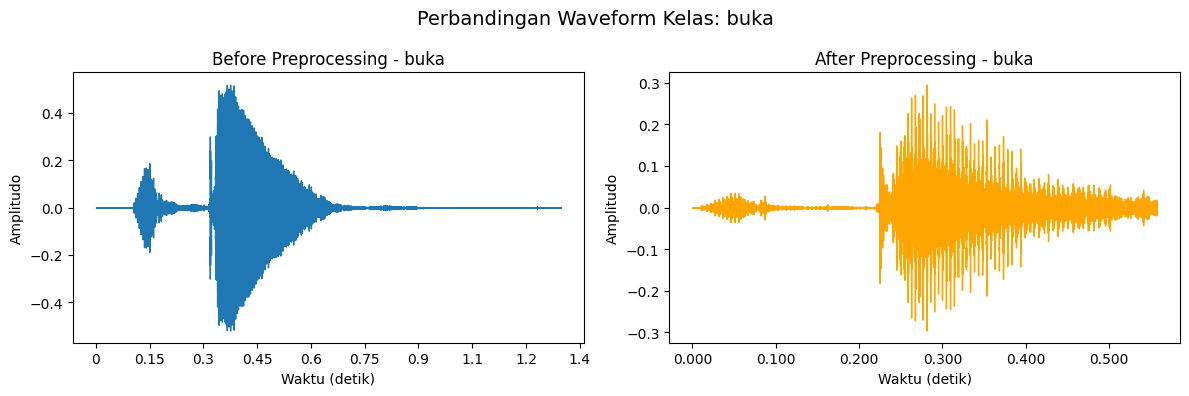

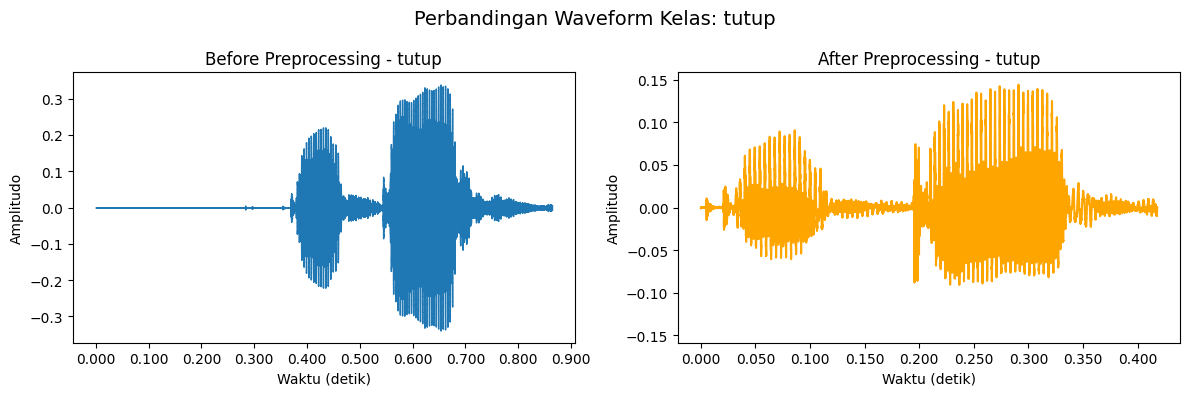


📊 Statistik dasar contoh pertama:
Sebelum Preprocessing:
Durasi (detik): 1.3
Mean          : -0.0000
Std Dev       : 0.0790
Skewness      : 0.4263
Kurtosis      : 9.5270

Sesudah Preprocessing:
Durasi (detik): 0.56
Mean          : -0.0000
Std Dev       : 0.0317
Skewness      : 1.5112
Kurtosis      : 11.5504


In [35]:
# === FOLDER ASAL DAN HASIL PREPROCESSING ===
FOLDER_ASLI = "suara"
FOLDER_PREPROCESSED = "suara_preprocessed"

# === PILIH KELAS UNTUK DITAMPILKAN ===
labels = ["buka", "tutup"]

# === SIMPAN AUDIO DARI KEDUA VERSI ===
audio_asli = []
audio_preprocessed = []
audio_labels = []

# Loop setiap kelas
for label in labels:
    asli_path = os.path.join(FOLDER_ASLI, label)
    prep_path = os.path.join(FOLDER_PREPROCESSED, label)

    # Ambil file pertama dari masing-masing kelas
    files_asli = sorted([f for f in os.listdir(asli_path) if f.endswith(".wav")])
    files_prep = sorted([f for f in os.listdir(prep_path) if f.endswith(".wav")])

    if not files_asli or not files_prep:
        print(f"⚠️ Folder '{label}' tidak berisi file audio lengkap.")
        continue

    # Ambil file pertama yang sesuai (misal buka1.wav)
    file_asli = os.path.join(asli_path, files_asli[0])
    file_prep = os.path.join(prep_path, files_prep[0])

    # Load keduanya
    y_asli, sr_asli = librosa.load(file_asli, sr=None)
    y_prep, sr_prep = librosa.load(file_prep, sr=None)

    audio_asli.append(y_asli)
    audio_preprocessed.append(y_prep)
    audio_labels.append(label)

    print(f"✅ Kelas '{label}': berhasil memuat '{files_asli[0]}' dan '{files_prep[0]}'")

# === VISUALISASI BEFORE vs AFTER ===
for i, label in enumerate(audio_labels):
    plt.figure(figsize=(12, 4))

    # Sebelum preprocessing
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(audio_asli[i], sr=sr_asli)
    plt.title(f"Before Preprocessing - {label}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")

    # Sesudah preprocessing
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(audio_preprocessed[i], sr=sr_prep, color='orange')
    plt.title(f"After Preprocessing - {label}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")

    plt.suptitle(f"Perbandingan Waveform Kelas: {label}", fontsize=14)
    plt.tight_layout()
    plt.show()

# === STATISTIK CONTOH (SEBELUM vs SESUDAH) ===
y_before = audio_asli[0]
y_after = audio_preprocessed[0]

print("\n📊 Statistik dasar contoh pertama:")
print("Sebelum Preprocessing:")
print(f"Durasi (detik): {round(len(y_before)/sr_asli, 2)}")
print(f"Mean          : {np.mean(y_before):.4f}")
print(f"Std Dev       : {np.std(y_before):.4f}")
print(f"Skewness      : {skew(y_before):.4f}")
print(f"Kurtosis      : {kurtosis(y_before):.4f}")

print("\nSesudah Preprocessing:")
print(f"Durasi (detik): {round(len(y_after)/sr_prep, 2)}")
print(f"Mean          : {np.mean(y_after):.4f}")
print(f"Std Dev       : {np.std(y_after):.4f}")
print(f"Skewness      : {skew(y_after):.4f}")
print(f"Kurtosis      : {kurtosis(y_after):.4f}")

### 6. Ekstraksi Fitur dan Penggabungan ke DataFrame
Mengubah sinyal audio menjadi representasi numerik (fitur).

In [36]:
from tabulate import tabulate  # buat tampilan tabel yang rapi di console

# === FUNGSI EKSTRAK FITUR ===
def extract_features(y, sr):
    """Ekstraksi fitur dasar dari sinyal audio."""
    features = {}
    # MFCC (13 koefisien)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}"] = np.mean(mfcc[i])
    # Zero Crossing Rate
    features["zero_crossing_rate"] = np.mean(librosa.feature.zero_crossing_rate(y))
    # Spectral Centroid
    features["spectral_centroid"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    # Spectral Rolloff
    features["spectral_rolloff"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)
    # RMS (energi rata-rata)
    features["rms"] = np.mean(librosa.feature.rms(y=y))
    # Durasi audio
    features["duration_sec"] = round(len(y) / sr, 2)
    return features


# === FUNGSI PROSES SEMUA KELAS ===
def process_all_classes(dataset_path):
    print(f"\n📂 Memproses dataset di folder: '{dataset_path}'")
    all_features = []
    summary = []

    # Loop tiap subfolder (kelas)
    for label in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, label)
        if not os.path.isdir(folder_path):
            continue  # skip jika bukan folder

        print(f"\n🔍 Kelas: {label}")
        print("-" * 50)
        success, failed = 0, 0

        files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".wav")])
        total_files = len(files)

        if total_files == 0:
            print(f"⚠️ Tidak ada file .wav di folder '{label}'")
            continue

        for idx, file_name in enumerate(files, start=1):
            file_path = os.path.join(folder_path, file_name)
            try:
                y, sr = librosa.load(file_path, sr=None)
                features = extract_features(y, sr)
                features["filename"] = file_name
                features["label"] = label
                all_features.append(features)
                print(f"[{idx:03}/{total_files}] ✅ {file_name} diekstraksi ({features['duration_sec']} detik)")
                success += 1
            except Exception as e:
                print(f"[{idx:03}/{total_files}] ❌ {file_name} gagal: {e}")
                failed += 1

        summary.append((label, success, failed, total_files))

    # === LAPORAN AKHIR ===
    print("\n" + "=" * 70)
    print("📊 RINGKASAN HASIL EKSTRAKSI")
    print("=" * 70)
    summary_table = [[lbl, s, f, t] for lbl, s, f, t in summary]
    print(tabulate(summary_table, headers=["Kelas", "Berhasil", "Gagal", "Total"], tablefmt="fancy_grid"))

    total_all = sum([t for _, _, _, t in summary])
    print(f"\n🎯 Total keseluruhan file diproses: {total_all} file\n")

    # Buat DataFrame
    df = pd.DataFrame(all_features)
    return df


# === EKSEKUSI UTAMA ===
if __name__ == "__main__":
    DATASET_PATH = "suara_preprocessed"  # gunakan dataset hasil preprocessing
    df_features = process_all_classes(DATASET_PATH)

    # Simpan hasil ke CSV
    output_csv = "fitur_suara_buka_tutup.csv"
    df_features.to_csv(output_csv, index=False)

    print(f"\n💾 Fitur berhasil disimpan ke: '{output_csv}'")

    # Tampilkan contoh hasil
    print("\n📋 Contoh hasil ekstraksi fitur:")
    print(tabulate(df_features.head(), headers="keys", tablefmt="rounded_outline", showindex=False))

print(" Semua library berhasil diimport!")



📂 Memproses dataset di folder: 'suara_preprocessed'

🔍 Kelas: buka
--------------------------------------------------
[001/110] ✅ buka 1.wav diekstraksi (0.56 detik)
[002/110] ✅ buka 57.wav diekstraksi (0.58 detik)
[003/110] ✅ buka10.wav diekstraksi (0.74 detik)
[004/110] ✅ buka100.wav diekstraksi (0.51 detik)
[005/110] ✅ buka101.wav diekstraksi (0.49 detik)
[006/110] ✅ buka102.wav diekstraksi (0.51 detik)
[007/110] ✅ buka103.wav diekstraksi (0.54 detik)
[008/110] ✅ buka104.wav diekstraksi (0.42 detik)
[009/110] ✅ buka105.wav diekstraksi (0.53 detik)
[010/110] ✅ buka106.wav diekstraksi (0.56 detik)
[011/110] ✅ buka107.wav diekstraksi (0.51 detik)
[012/110] ✅ buka108.wav diekstraksi (0.51 detik)
[013/110] ✅ buka109.wav diekstraksi (0.58 detik)
[014/110] ✅ buka11.wav diekstraksi (0.79 detik)
[015/110] ✅ buka110.wav diekstraksi (0.51 detik)
[016/110] ✅ buka12.wav diekstraksi (0.7 detik)
[017/110] ✅ buka13.wav diekstraksi (0.74 detik)
[018/110] ✅ buka14.wav diekstraksi (0.72 detik)
[019/1

### 7. EDA (Exploratory Data Analysis)
Memahami struktur, pola, distribusi, dan hubungan antar fitur (MFCC, ZCR, RMS, dll.) dari dataset audio yang sudah diekstraksi.

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mfcc_1              220 non-null    float64
 1   mfcc_2              220 non-null    float64
 2   mfcc_3              220 non-null    float64
 3   mfcc_4              220 non-null    float64
 4   mfcc_5              220 non-null    float64
 5   mfcc_6              220 non-null    float64
 6   mfcc_7              220 non-null    float64
 7   mfcc_8              220 non-null    float64
 8   mfcc_9              220 non-null    float64
 9   mfcc_10             220 non-null    float64
 10  mfcc_11             220 non-null    float64
 11  mfcc_12             220 non-null    float64
 12  mfcc_13             220 non-null    float64
 13  zero_crossing_rate  220 non-null    float64
 14  spectral_centroid   220 non-null    float64
 15  spectral_rolloff    220 non-null    

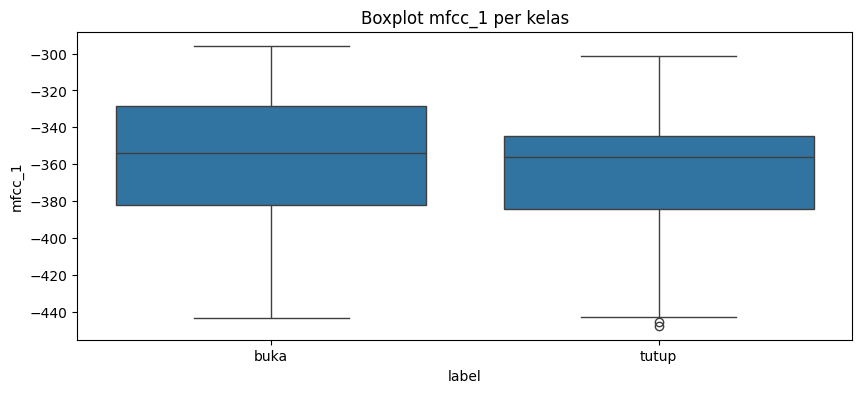

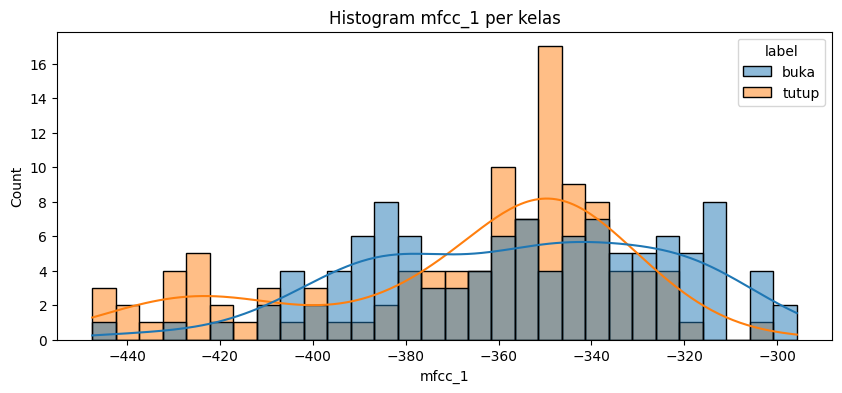

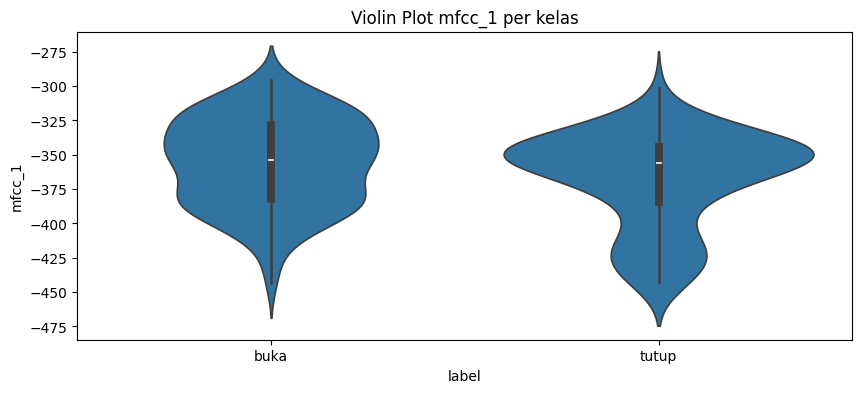

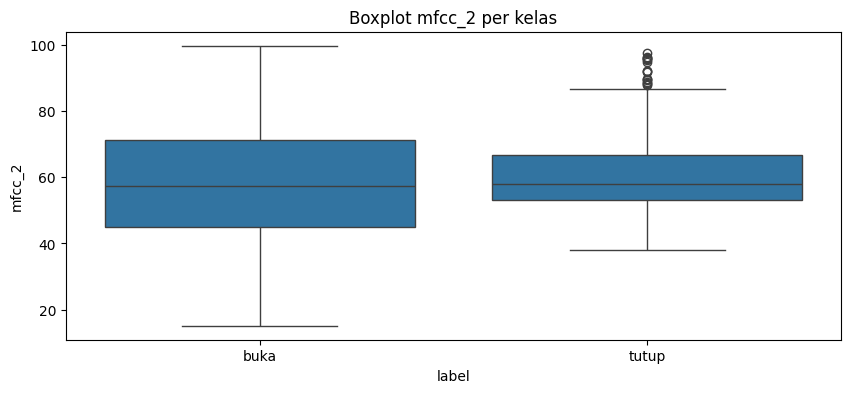

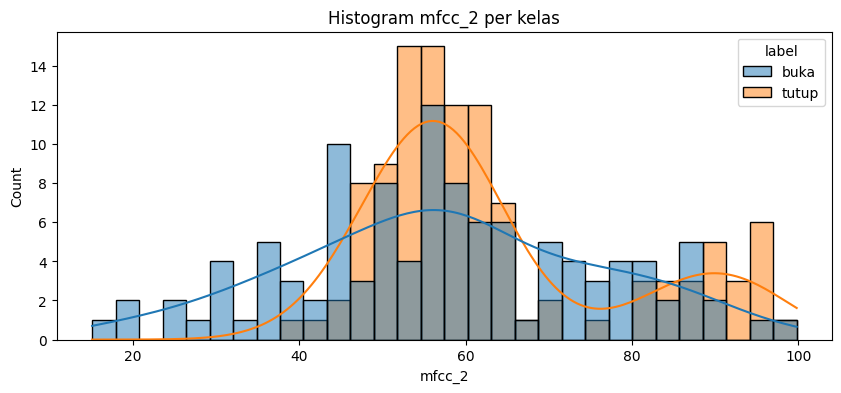

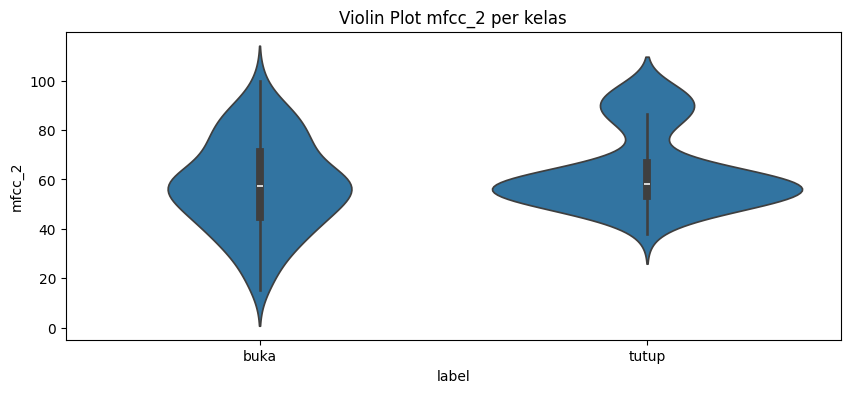

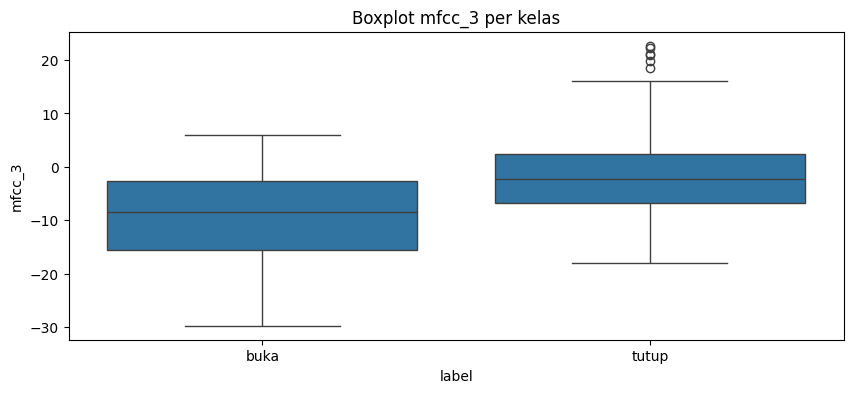

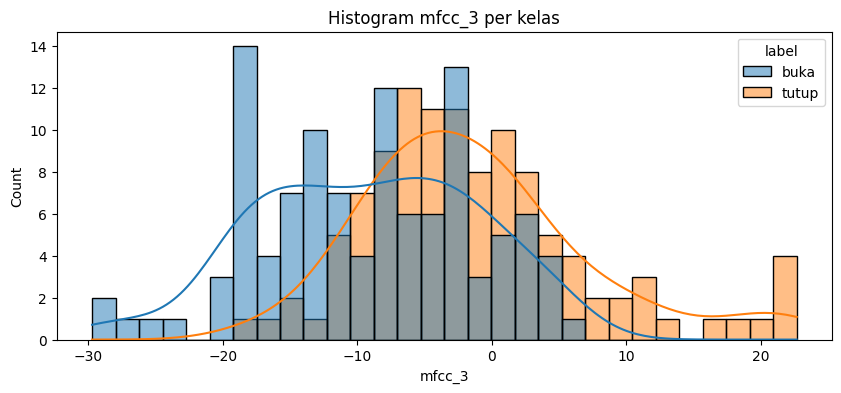

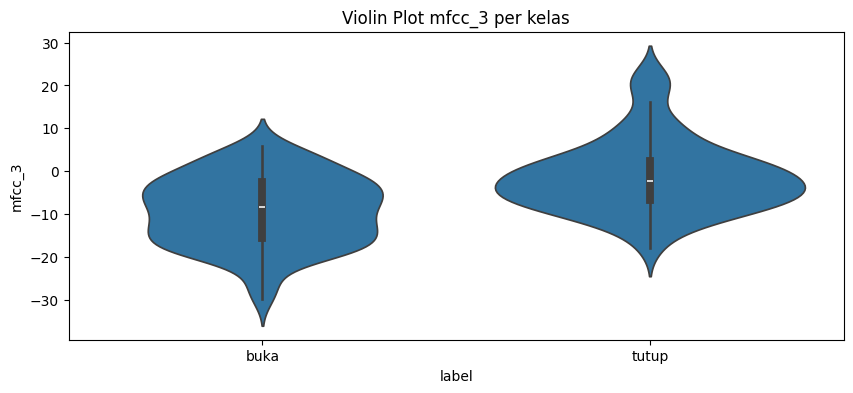

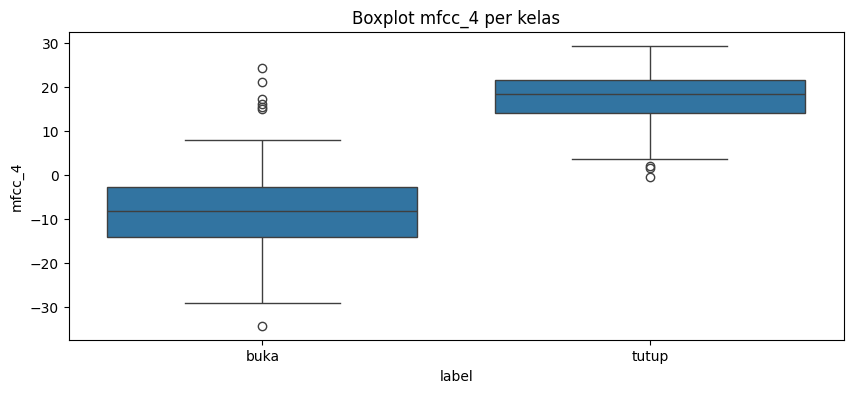

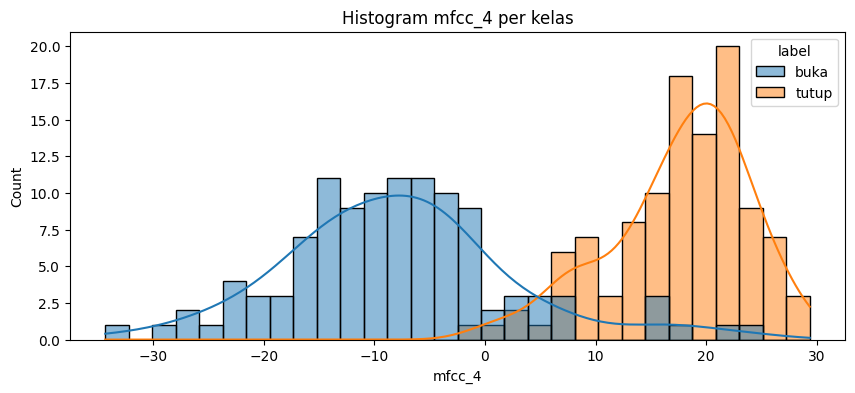

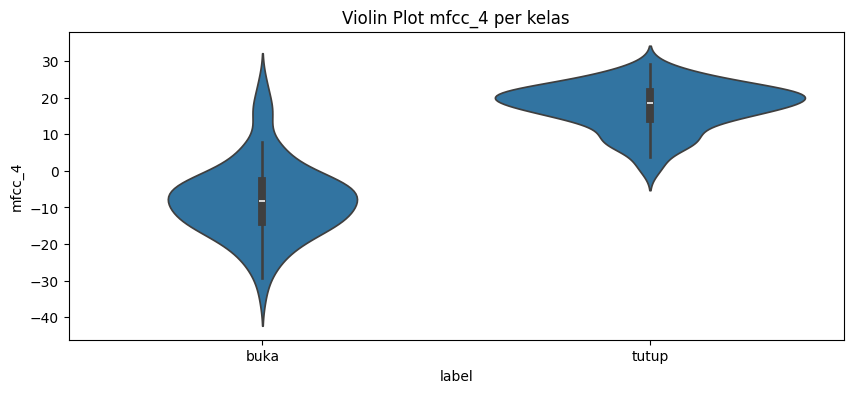

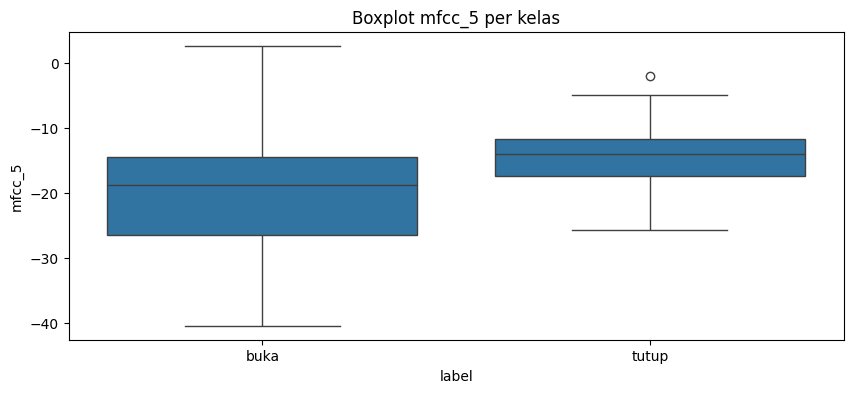

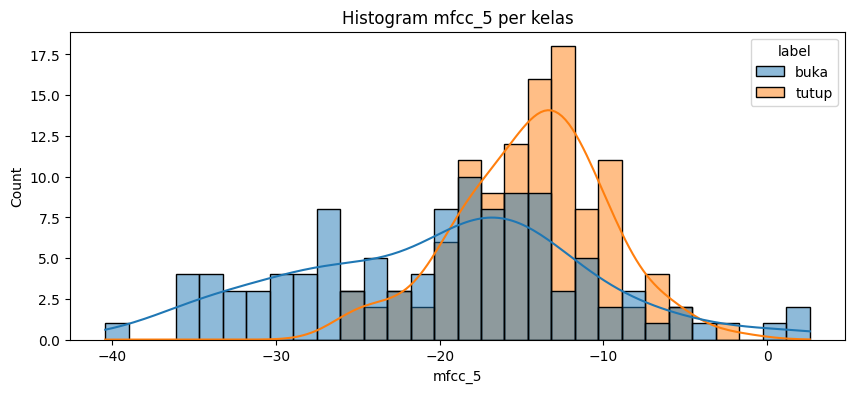

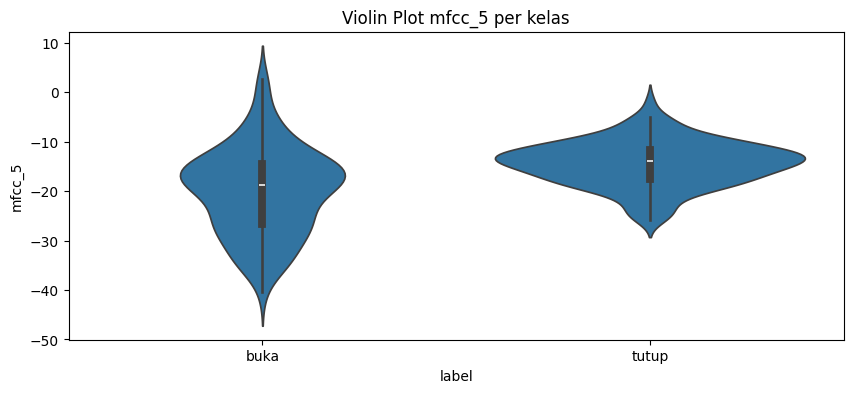

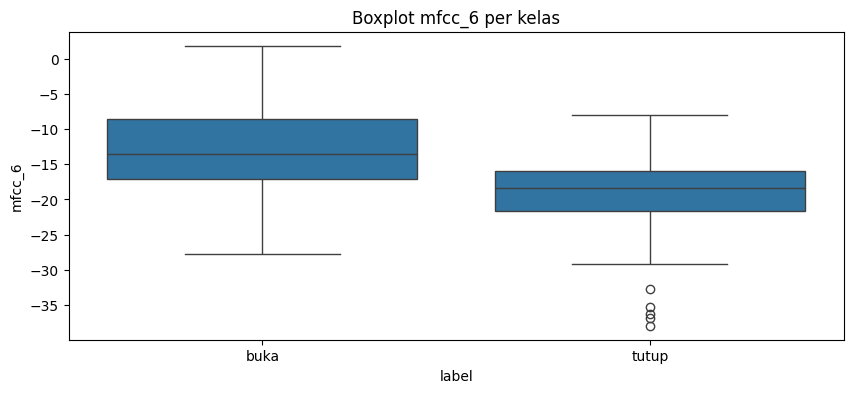

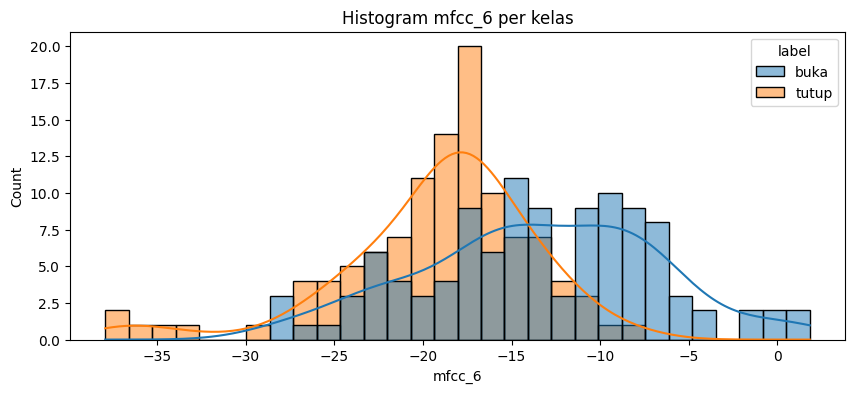

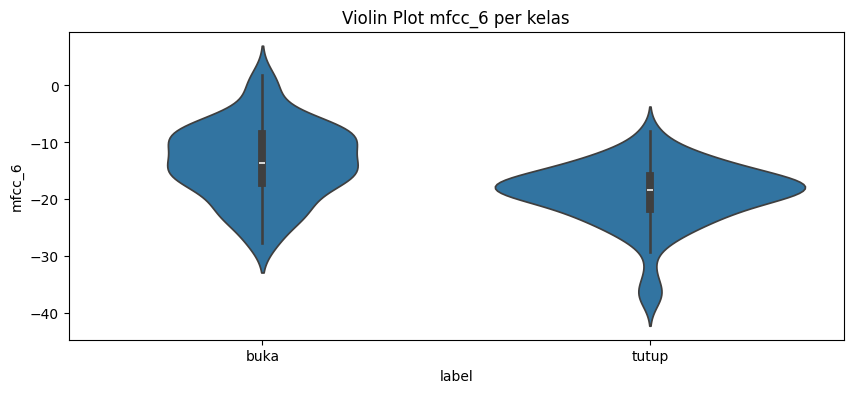

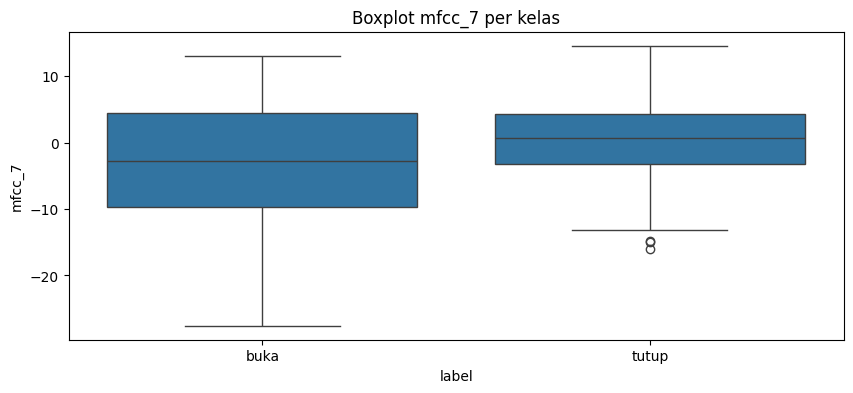

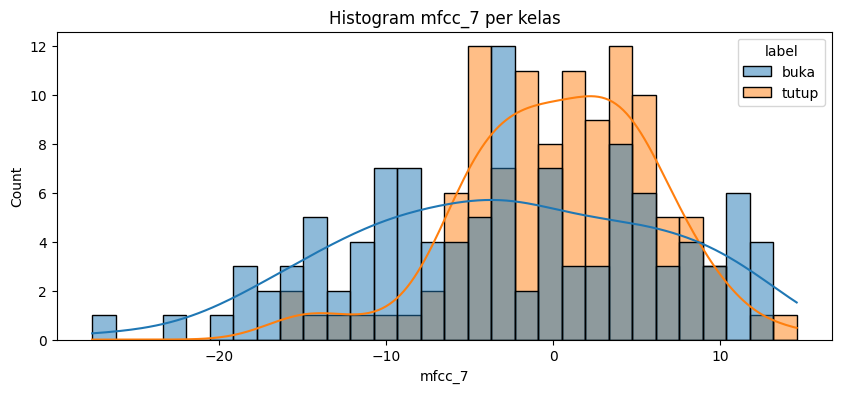

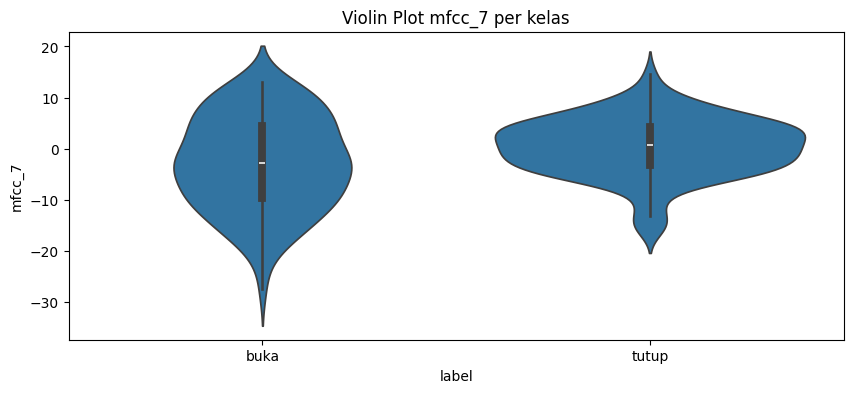

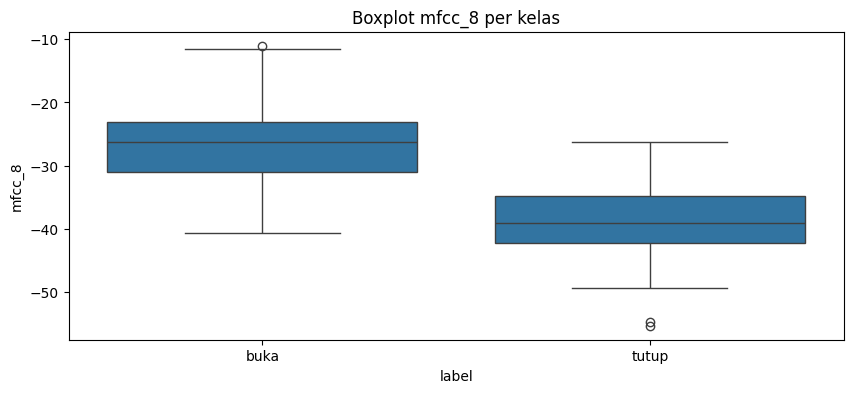

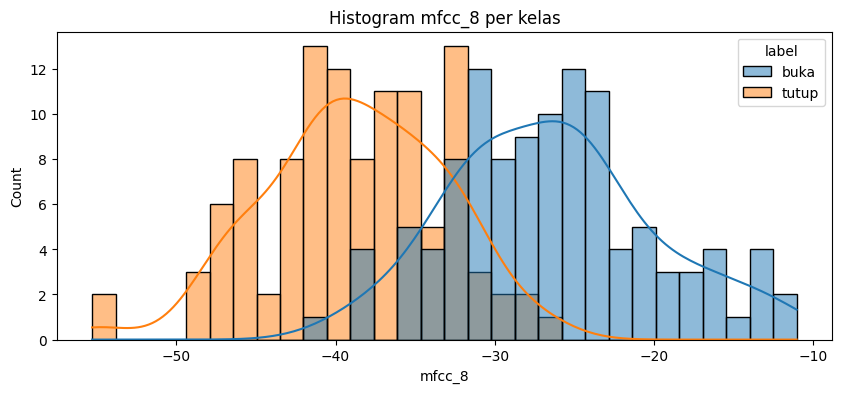

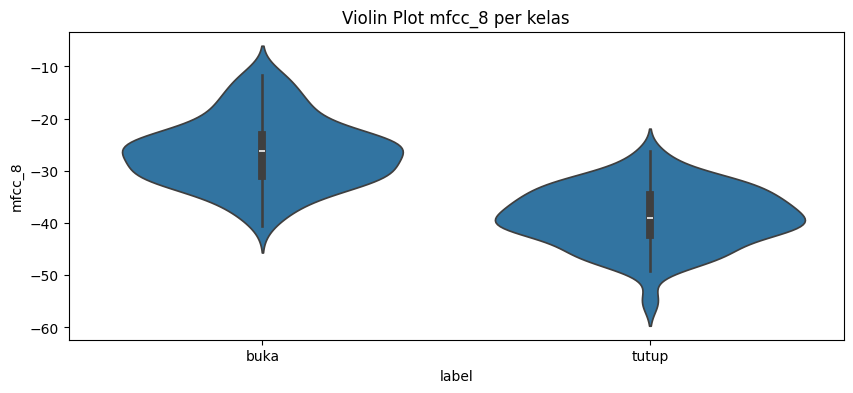

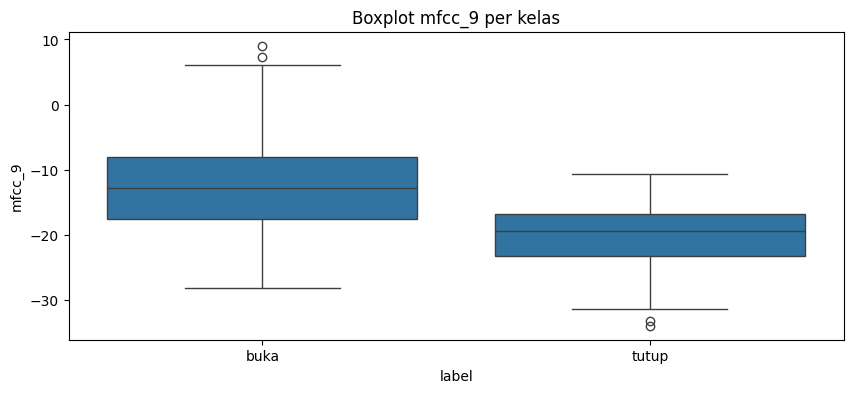

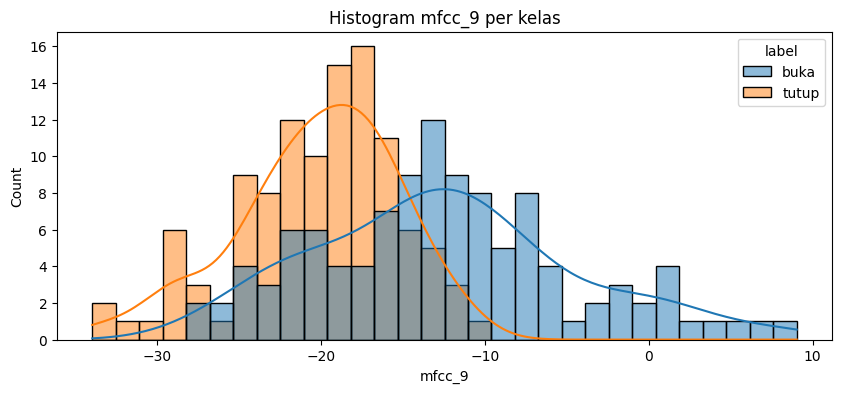

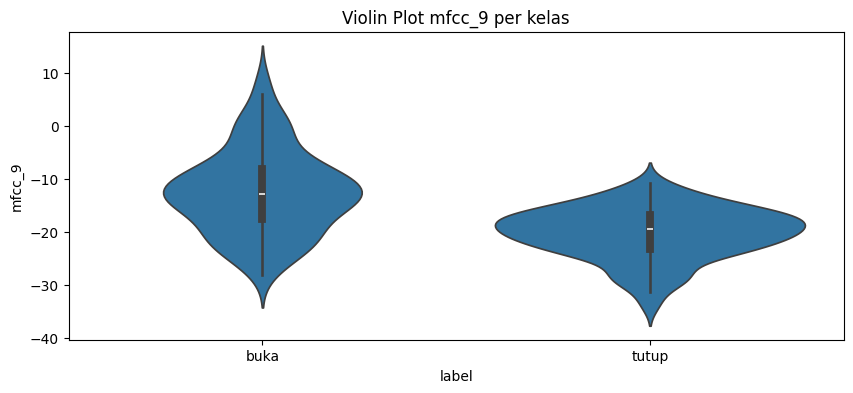

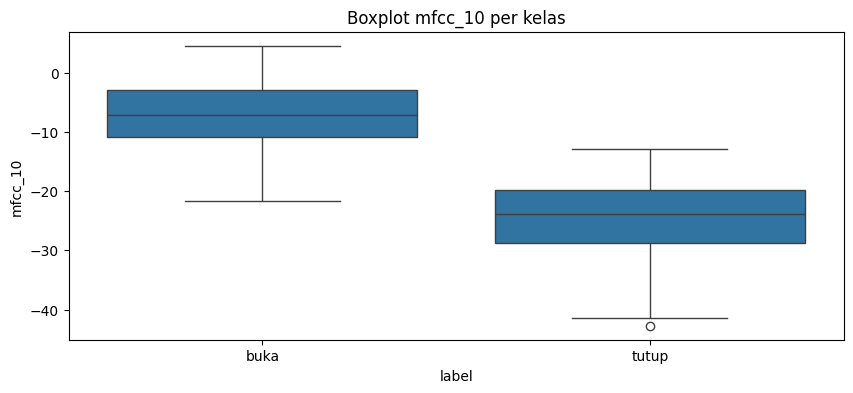

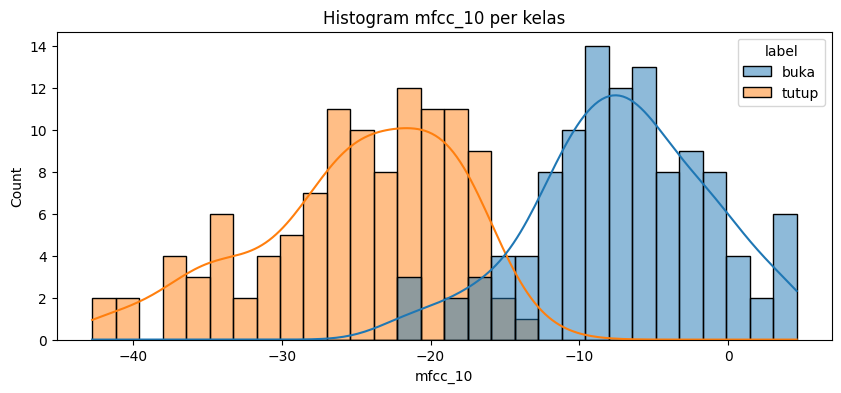

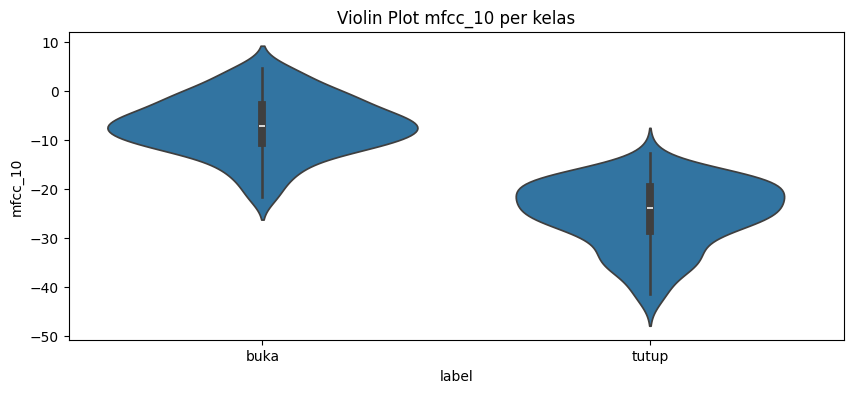

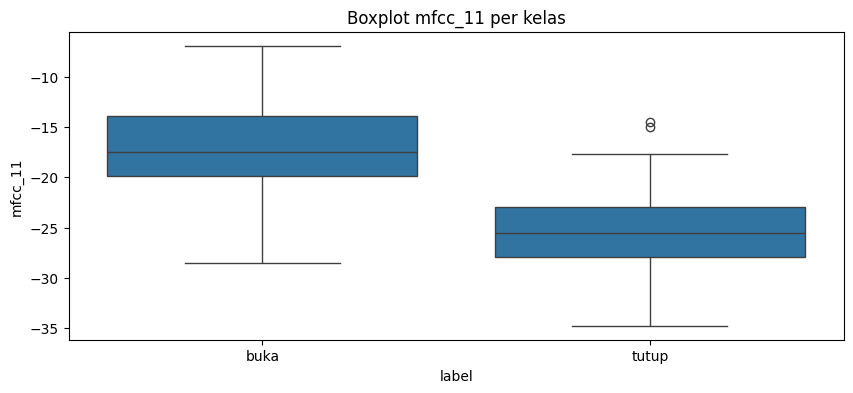

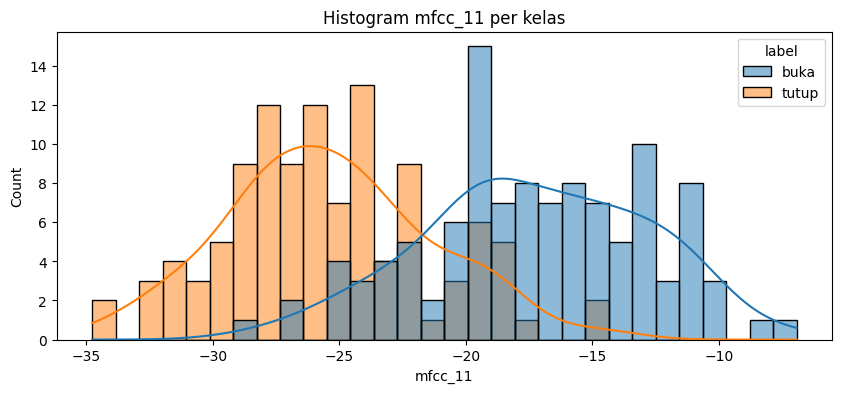

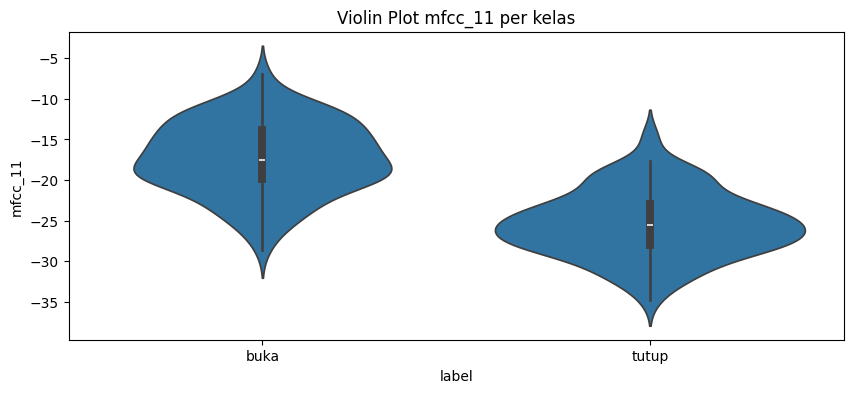

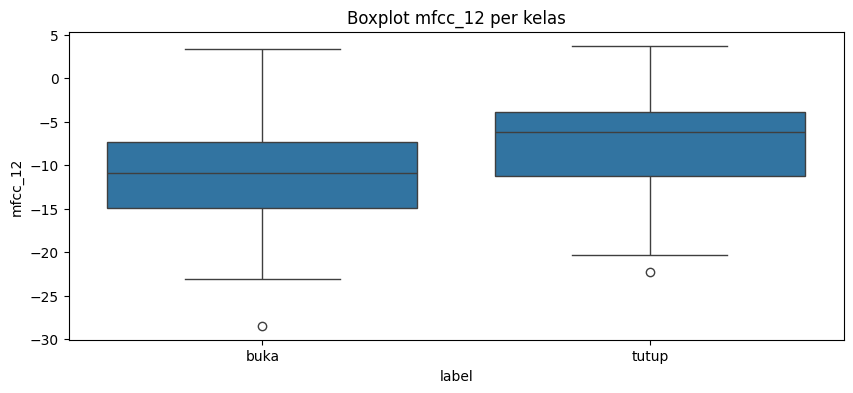

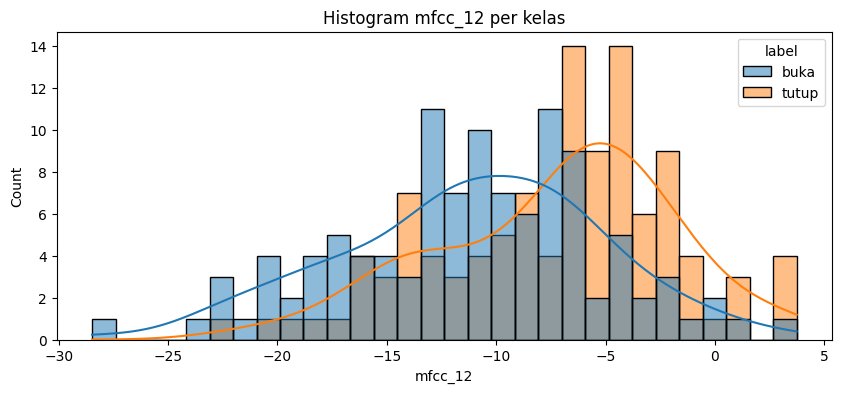

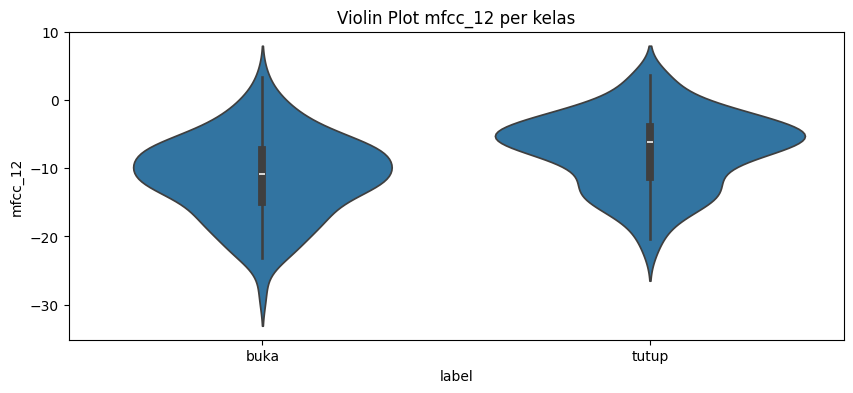

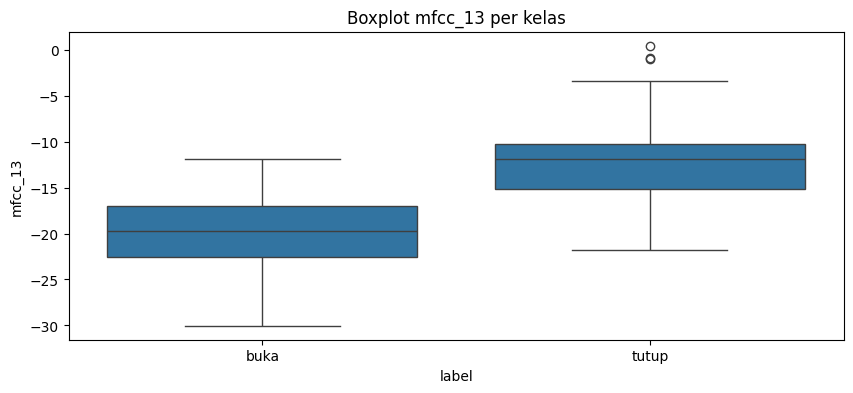

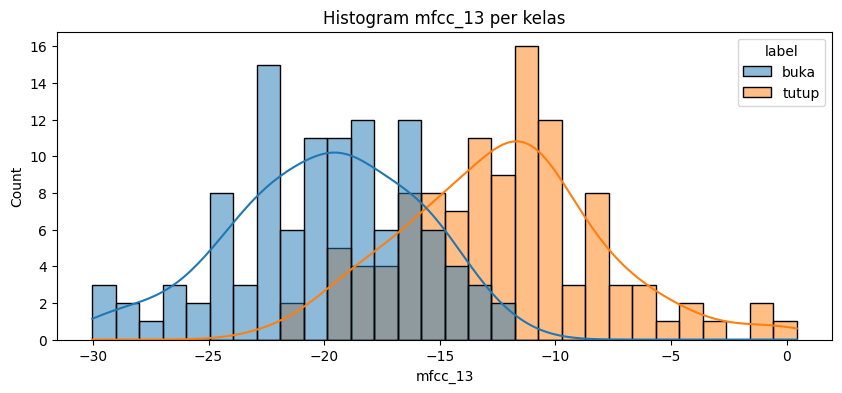

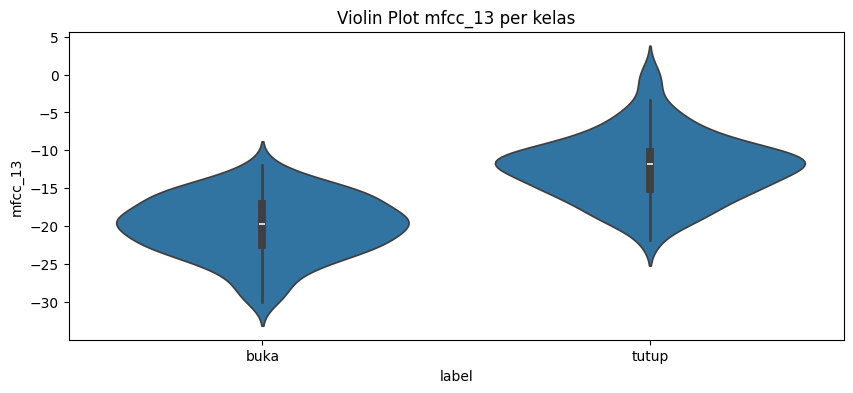

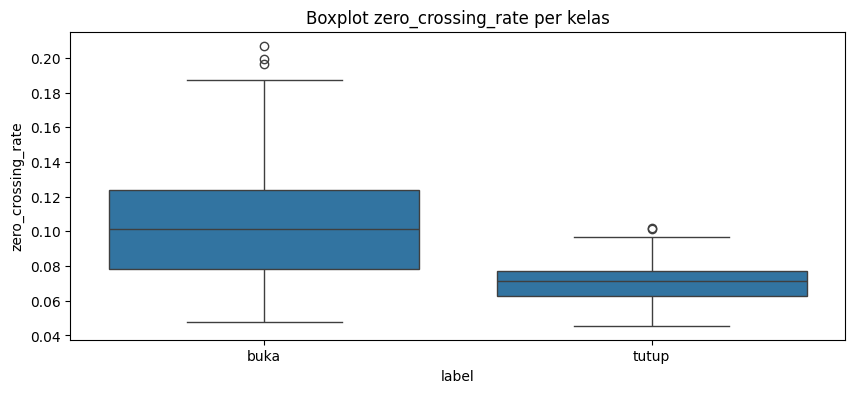

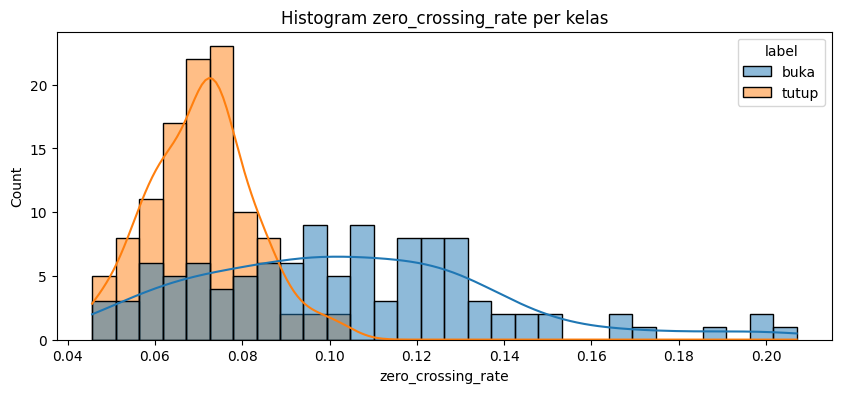

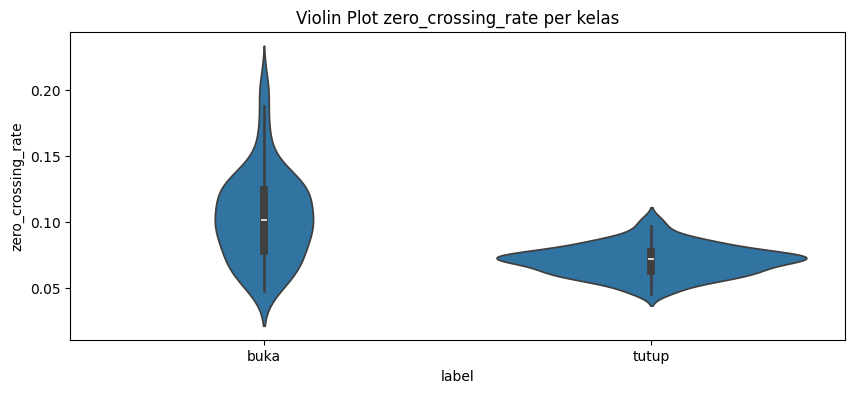

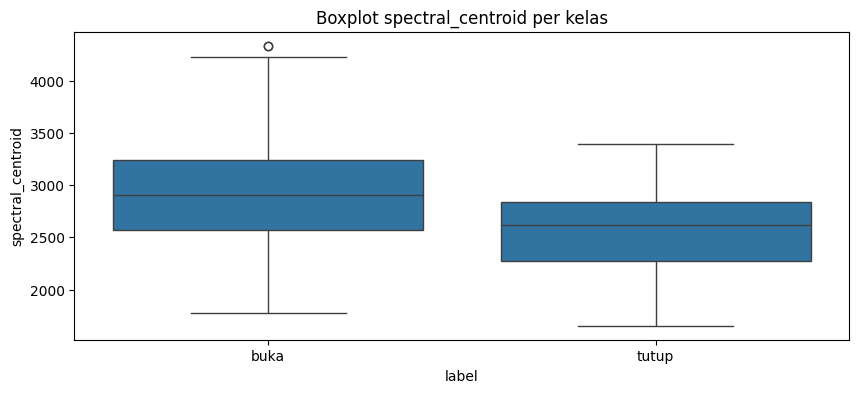

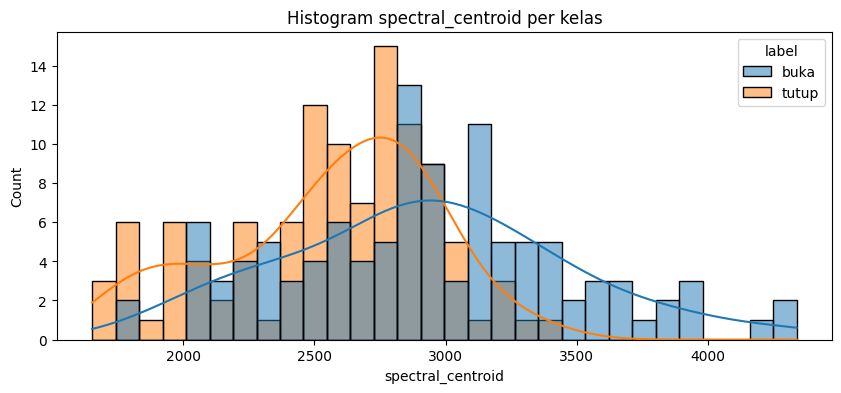

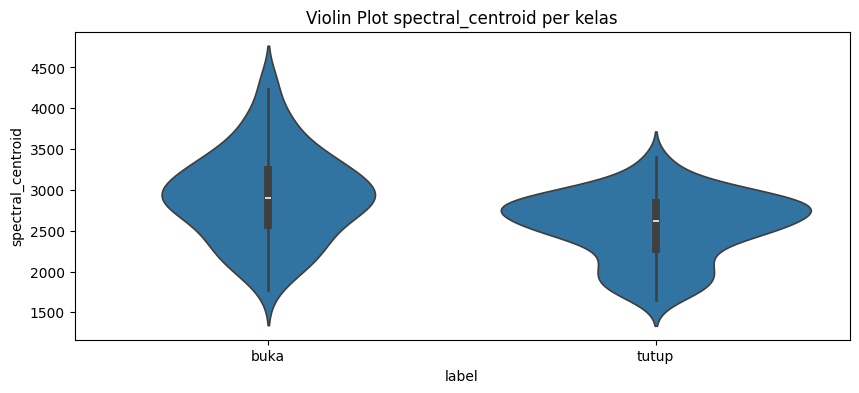

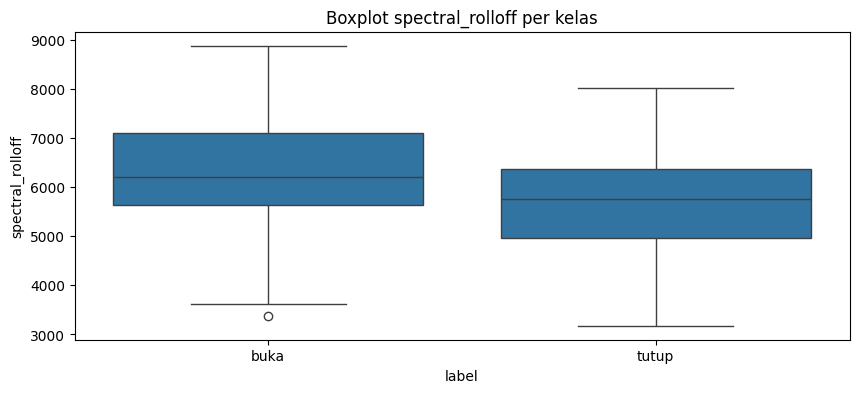

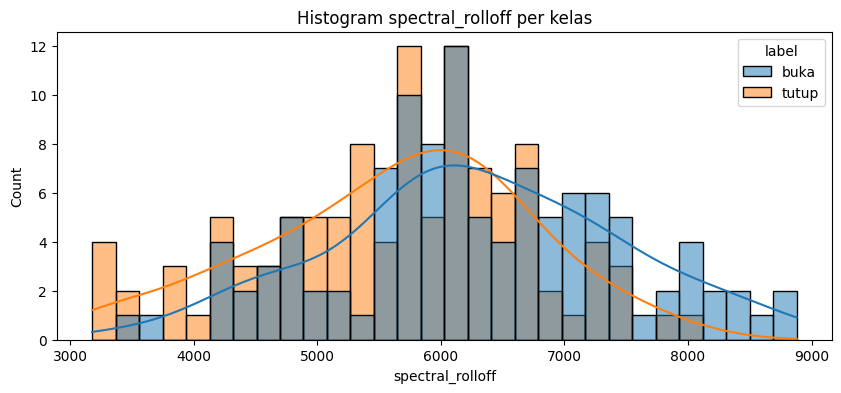

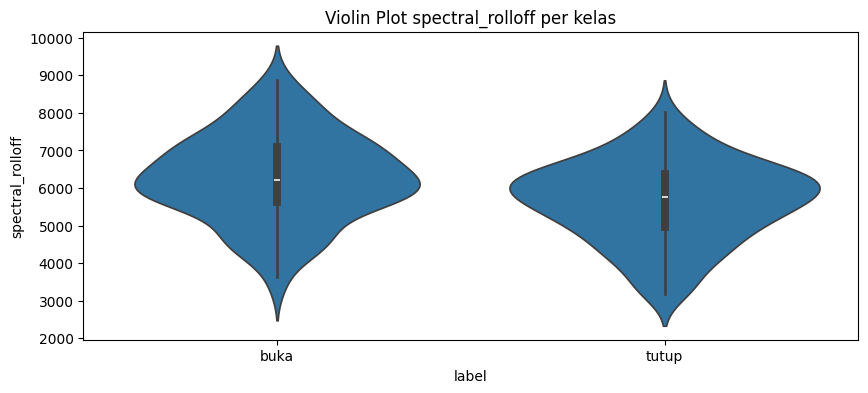

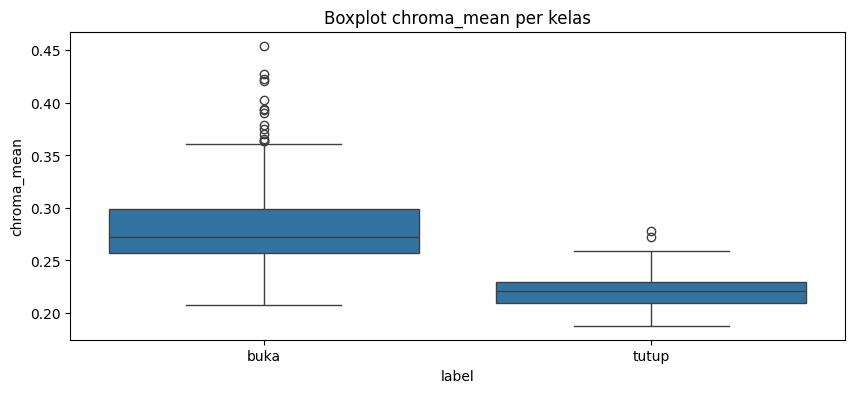

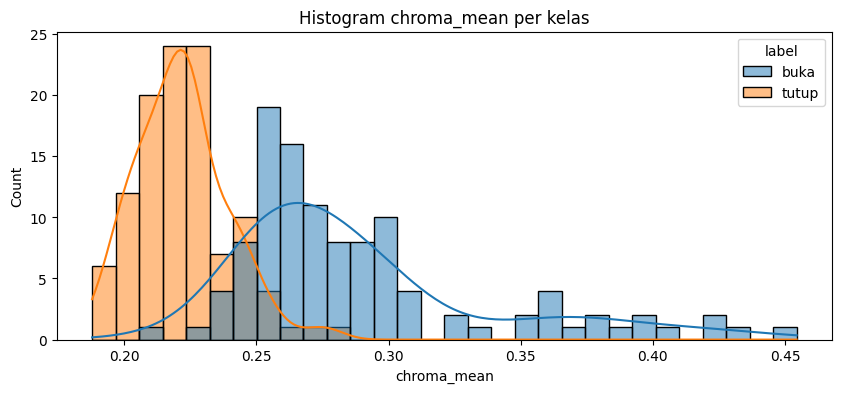

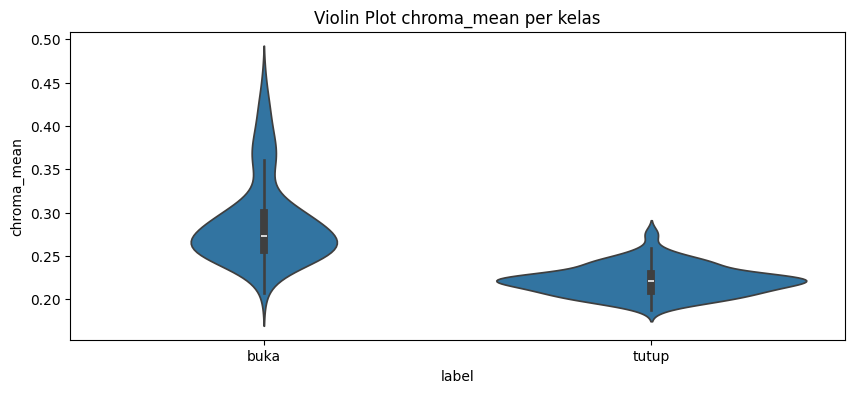

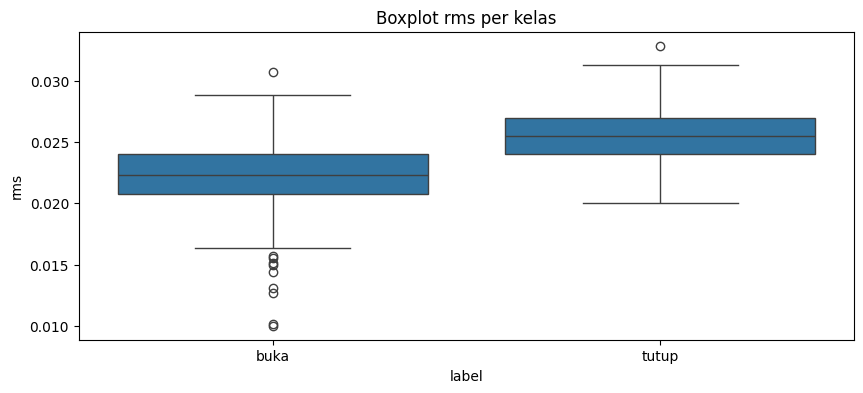

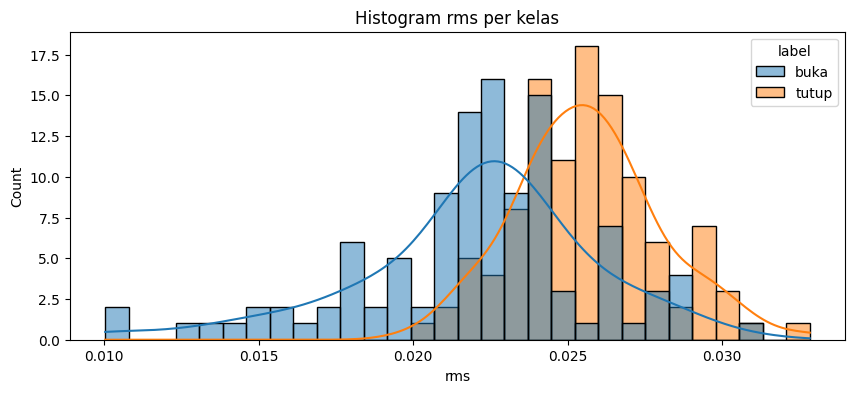

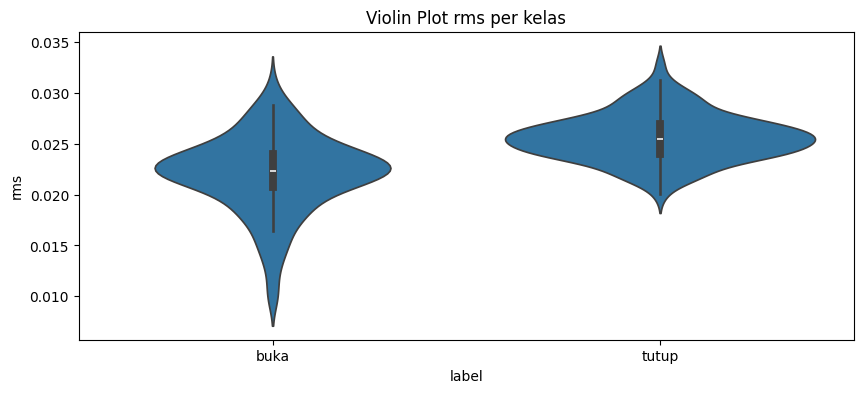

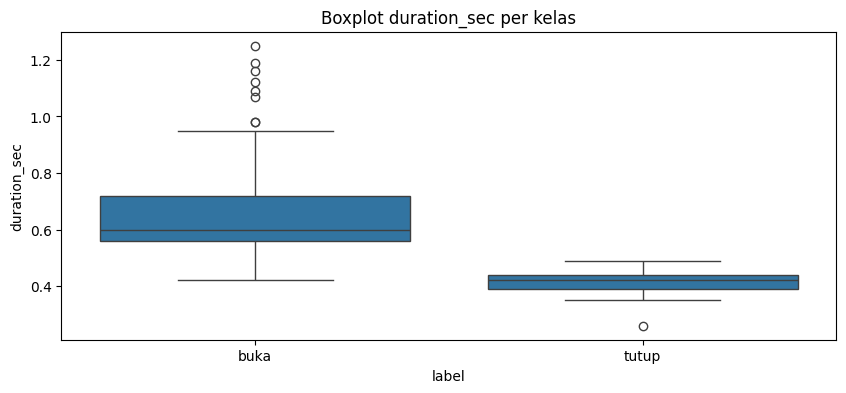

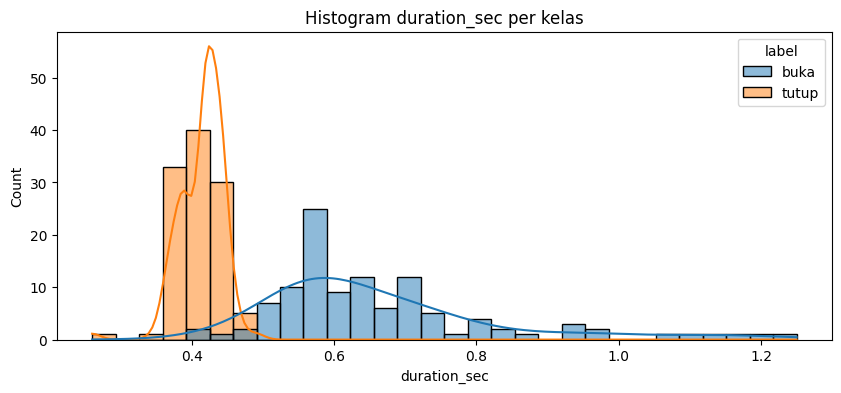

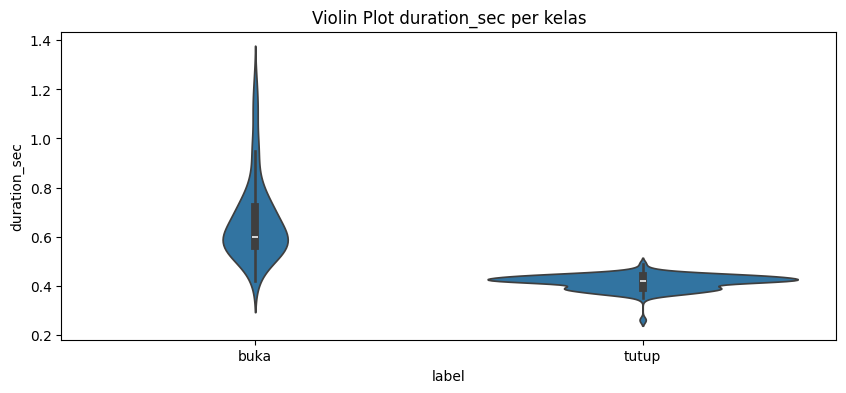

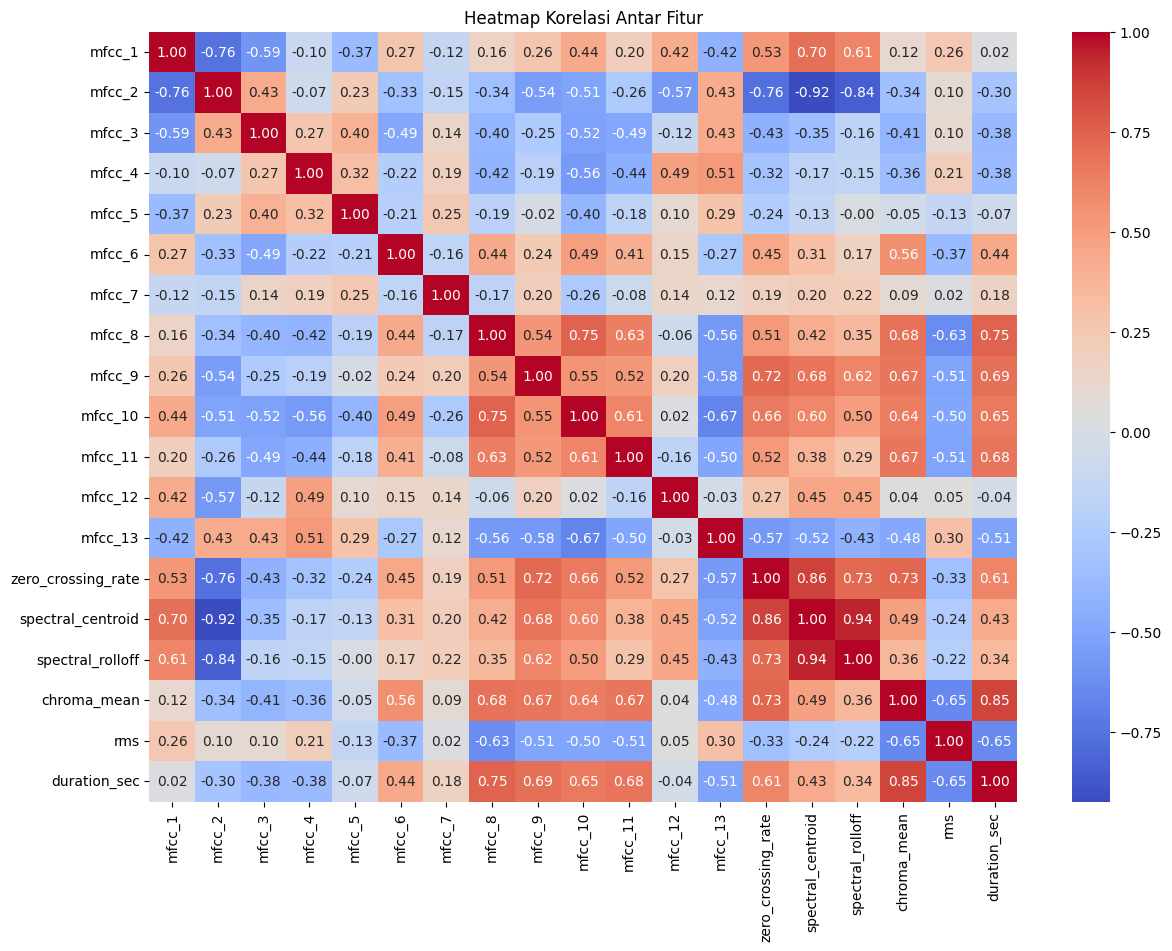


=== Jumlah Outlier per Fitur (IQR) ===
+----+--------------------+-----------+------------------+
|    | Fitur              |   Outlier |   Persentase (%) |
|----+--------------------+-----------+------------------|
|  0 | mfcc_1             |         0 |             0    |
|  1 | mfcc_2             |         4 |             1.82 |
|  2 | mfcc_3             |         7 |             3.18 |
|  3 | mfcc_4             |         0 |             0    |
|  4 | mfcc_5             |        13 |             5.91 |
|  5 | mfcc_6             |         9 |             4.09 |
|  6 | mfcc_7             |         3 |             1.36 |
|  7 | mfcc_8             |         0 |             0    |
|  8 | mfcc_9             |         7 |             3.18 |
|  9 | mfcc_10            |         0 |             0    |
| 10 | mfcc_11            |         0 |             0    |
| 11 | mfcc_12            |         1 |             0.45 |
| 12 | mfcc_13            |         1 |             0.45 |
| 13 | zero_cros

In [37]:
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load dataset
# =========================
df = pd.read_csv("fitur_suara_buka_tutup.csv")

# =========================
# 2. Ringkasan Data
# =========================
print("=== Info Dataset ===")
print(df.info())  # info() tidak bisa tabulate, cukup tampilkan

print("\n=== Statistik Deskriptif ===")
print(tabulate(df.describe(), headers='keys', tablefmt='psql'))

# =========================
# 3. Missing Values + Persentase
# =========================
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Fitur', 'Missing']
missing_df['Persentase (%)'] = (missing_df['Missing'] / len(df) * 100).round(2)
print("\n=== Missing Values per Fitur ===")
print(tabulate(missing_df, headers='keys', tablefmt='psql'))

# =========================
# 4. Jumlah Data per Kelas
# =========================
class_count = df['label'].value_counts().reset_index()
class_count.columns = ['Label', 'Jumlah']
print("\n=== Jumlah Data per Kelas ===")
print(tabulate(class_count, headers='keys', tablefmt='psql'))

# =========================
# 5. Pilih kolom numerik
# =========================
numerik_cols = df.select_dtypes(include='number').columns.tolist()

# =========================
# 6. Analisis Mean & Std per Kelas
# =========================
mean_std = df.groupby('label')[numerik_cols].agg(['mean','std'])
print("\n=== Mean & Std per Kelas ===")
print(tabulate(mean_std, headers='keys', tablefmt='psql'))

# =========================
# 7. Visualisasi Distribusi Fitur
# =========================
for fitur in numerik_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x='label', y=fitur, data=df)
    plt.title(f"Boxplot {fitur} per kelas")
    plt.show()

    plt.figure(figsize=(10,4))
    sns.histplot(data=df, x=fitur, hue='label', kde=True, bins=30)
    plt.title(f"Histogram {fitur} per kelas")
    plt.show()

    plt.figure(figsize=(10,4))
    sns.violinplot(x='label', y=fitur, data=df)
    plt.title(f"Violin Plot {fitur} per kelas")
    plt.show()

# =========================
# 8. Korelasi antar fitur
# =========================
plt.figure(figsize=(14,10))
sns.heatmap(df[numerik_cols].corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

# =========================
# 9. Analisis Outlier (IQR) + Persentase
# =========================
outliers_iqr = {}
for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_iqr[col] = {'Outlier': count, 'Persentase (%)': round(count/len(df)*100,2)}

outlier_df = pd.DataFrame.from_dict(outliers_iqr, orient='index').reset_index()
outlier_df.rename(columns={'index':'Fitur'}, inplace=True)
print("\n=== Jumlah Outlier per Fitur (IQR) ===")
print(tabulate(outlier_df, headers='keys', tablefmt='psql'))

# =========================
# 10. Tindak Lanjut Outlier (Capping)
# =========================
df_capped = df.copy()
for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df_capped[col] = df[col].clip(lower, upper)  # capping

print("\n=== Outlier sudah dicapping (tidak dihapus) ===")

# =========================
# 11. Data Siap untuk Normalisasi & Split
# =========================
print("\nEDA selesai. Data sudah siap untuk normalisasi & split train/test.")


### 8. Feature Selection
untuk memilih fitur paling penting supaya model lebih akurat, cepat, dan mudah dipahami.

=== Tabel Feature Importance ===
                 Fitur  Importance
0         duration_sec    0.247694
1              mfcc_10    0.187198
2               mfcc_4    0.156744
3          chroma_mean    0.114403
4               mfcc_8    0.093232
5              mfcc_13    0.058377
6              mfcc_11    0.043932
7   zero_crossing_rate    0.021192
8                  rms    0.018007
9               mfcc_9    0.015902
10              mfcc_3    0.010437
11             mfcc_12    0.009272
12              mfcc_5    0.005547
13              mfcc_2    0.005500
14   spectral_centroid    0.004632
15              mfcc_7    0.002488
16              mfcc_6    0.002088
17    spectral_rolloff    0.001935
18              mfcc_1    0.001420


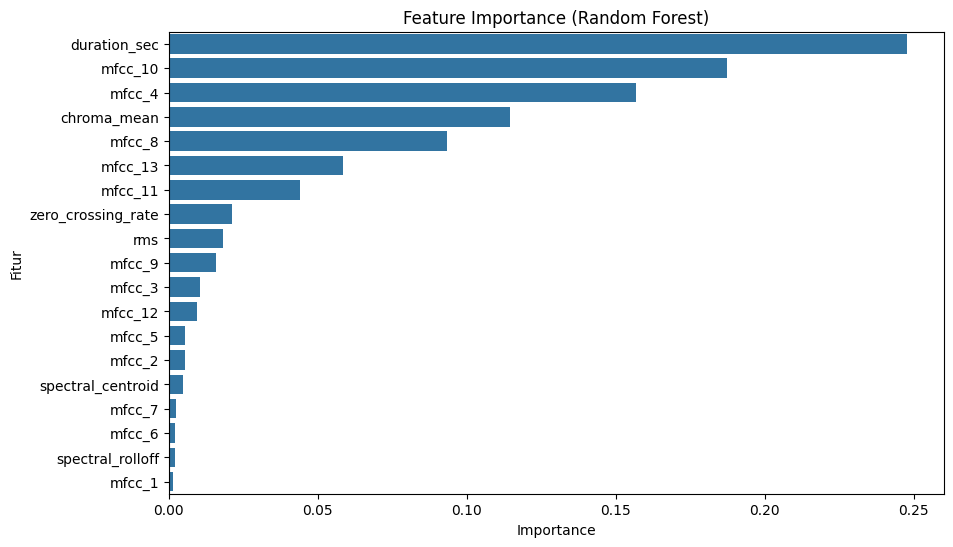


Fitur terpilih (Top 10): ['duration_sec', 'mfcc_10', 'mfcc_4', 'chroma_mean', 'mfcc_8', 'mfcc_13', 'mfcc_11', 'zero_crossing_rate', 'rms', 'mfcc_9']


In [38]:
# =========================
# TAHAP FEATURE SELECTION
# =========================

# 2. Siapkan dataset (pakai df_capped dari EDA)
X_fs = df_capped[numerik_cols]  # semua fitur numerik
y_fs = df_capped['label']

# 3. Training sementara Random Forest untuk menentukan importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs, y_fs)

# 4. Ambil nilai importance dan urutkan
importances = rf_fs.feature_importances_
feat_importance = pd.Series(importances, index=numerik_cols).sort_values(ascending=False)

# 5. Tampilkan tabel fitur penting
importance_df = pd.DataFrame({
    'Fitur': feat_importance.index,
    'Importance': feat_importance.values
})
print("=== Tabel Feature Importance ===")
print(importance_df)

# 6. Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

# 7. Pilih top N fitur (misal top 10) untuk model training
top_n = 10
selected_features = feat_importance.head(top_n).index.tolist()
print(f"\nFitur terpilih (Top {top_n}): {selected_features}")


### 9. NORMALISASI & SPLIT DATASET

In [41]:
# =========================
# NORMALISASI & SPLIT DATASET
# =========================

# =========================
# Siapkan fitur & label
# =========================
selected_features = ['duration_sec', 'mfcc_10', 'mfcc_4', 'chroma_mean', 
                     'mfcc_8', 'mfcc_13', 'mfcc_11', 'zero_crossing_rate', 
                     'rms', 'mfcc_9']

X = df_capped[selected_features]  # hanya fitur terpilih
y = df_capped['label']            # kolom label

# Ringkasan fitur
print("=== Info Dataset Fitur (X) ===")
print(tabulate(pd.DataFrame(X.describe()).reset_index(), headers='keys', tablefmt='psql'))

# Ringkasan label
label_count = y.value_counts().reset_index()
label_count.columns = ['Label', 'Jumlah']
print("\n=== Jumlah Data per Kelas (y) ===")
print(tabulate(label_count, headers='keys', tablefmt='psql'))

# =========================
# Normalisasi fitur (Min-Max Scaling)
# =========================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Simpan scaler untuk digunakan saat prediksi data baru
joblib.dump(scaler, "scaler.pkl")

# Simpan ke DataFrame supaya mudah ditampilkan
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print("\n=== Dataset Fitur Setelah Normalisasi (5 sample pertama) ===")
print(tabulate(X_scaled_df.head(), headers='keys', tablefmt='psql', showindex=True))

# =========================
# Split dataset menjadi Train/Test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Ringkasan ukuran dataset
split_summary = pd.DataFrame({
    'Subset': ['X_train', 'X_test', 'y_train', 'y_test'],
    'Baris': [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
    'Kolom': [X_train.shape[1], X_test.shape[1], 1, 1]
})
print("\n=== Ukuran Dataset Setelah Split ===")
print(tabulate(split_summary, headers='keys', tablefmt='psql'))

print("\n=== Tahap Normalisasi & Split selesai. Data siap untuk Model Training ===")


=== Info Dataset Fitur (X) ===
+----+---------+----------------+-----------+-----------+---------------+-----------+------------+-----------+----------------------+--------------+------------+
|    | index   |   duration_sec |   mfcc_10 |    mfcc_4 |   chroma_mean |    mfcc_8 |    mfcc_13 |   mfcc_11 |   zero_crossing_rate |          rms |     mfcc_9 |
|----+---------+----------------+-----------+-----------+---------------+-----------+------------+-----------+----------------------+--------------+------------|
|  0 | count   |     220        | 220       | 220       |   220         | 220       | 220        | 220       |          220         | 220          | 220        |
|  1 | mean    |       0.529364 | -16.0449  |   4.85907 |     0.25248   | -32.5949  | -16.1536   | -21.3331  |            0.0861687 |   0.0239459  | -16.4397   |
|  2 | std     |       0.143545 |  10.9491  |  15.3107  |     0.0417582 |   8.65889 |   5.67271  |   5.87847 |            0.0271351 |   0.00329575 |   7.30365 

### 10. Model Training menggunakan Random Forest

In [42]:
# =========================
# MODEL TRAINING (RANDOM FOREST)
# =========================

# =========================
# Import library
# =========================
from sklearn.ensemble import RandomForestClassifier
import joblib

# =========================
# Inisialisasi model Random Forest (dengan class_weight)
# =========================
rf_model = RandomForestClassifier(
    n_estimators=300,        # jumlah pohon lebih banyak untuk stabilitas
    random_state=42,         # untuk reproduksibilitas
    max_depth=None,          # None = biarkan pohon tumbuh sampai optimal
    min_samples_split=2,     
    min_samples_leaf=1,      
    n_jobs=-1,               # gunakan semua core CPU
    class_weight='balanced'  # ✅ penting agar model tidak berat sebelah ke 'buka'
)

# =========================
# Latih model dengan data train
# =========================
rf_model.fit(X_train, y_train)

# =========================
# Simpan model Random Forest
# =========================
joblib.dump(rf_model, "rf_model.pkl")

# =========================
# Tampilkan ringkasan model
# =========================
print("=== Random Forest Model Training Selesai ===")
print(f"Jumlah pohon: {len(rf_model.estimators_)}")
print(f"Fitur digunakan: {X_train.shape[1]} kolom")
print("Model tersimpan sebagai 'rf_model.pkl'")


=== Random Forest Model Training Selesai ===
Jumlah pohon: 300
Fitur digunakan: 10 kolom
Model tersimpan sebagai 'rf_model.pkl'


### 11. Evaluasi Model

=== Tabel Metrik Evaluasi Model ===
+----+-----------+---------+
|    | Metrik    |   Nilai |
|----+-----------+---------|
|  0 | Accuracy  |       1 |
|  1 | Precision |       1 |
|  2 | Recall    |       1 |
|  3 | F1-score  |       1 |
+----+-----------+---------+

=== Confusion Matrix ===
+---------+--------+---------+
| index   |   buka |   tutup |
|---------+--------+---------|
| buka    |     22 |       0 |
| tutup   |      0 |      22 |
+---------+--------+---------+


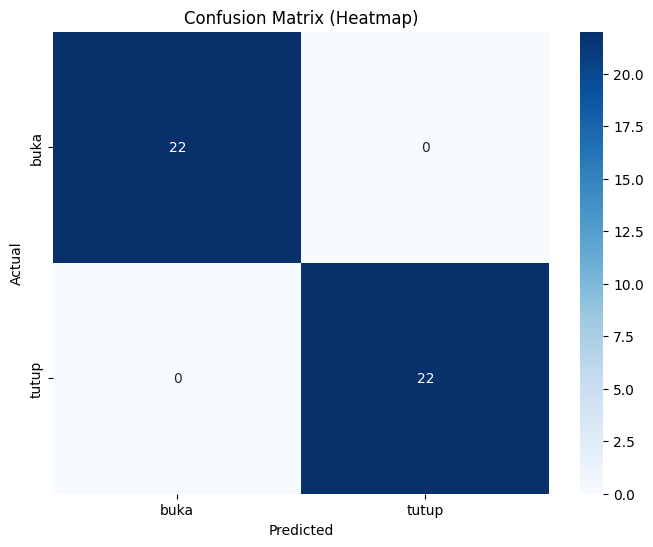

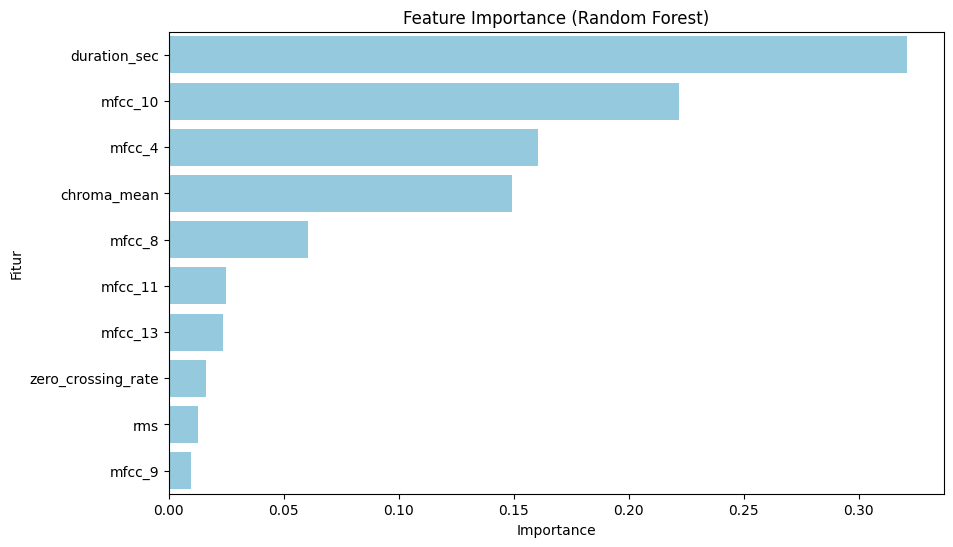


=== Evaluasi Model Selesai ===


In [50]:
# =========================
# EVALUASI MODEL RANDOM FOREST
# =========================


# =========================
# Prediksi pada data test
# =========================
y_pred = rf_model.predict(X_test)

# =========================
# Hitung metrik evaluasi
# =========================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Nilai": [accuracy, precision, recall, f1]
})

print("=== Tabel Metrik Evaluasi Model ===")
print(tabulate(metrics_df, headers='keys', tablefmt='psql'))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=rf_model.classes_, columns=rf_model.classes_)

print("\n=== Confusion Matrix ===")
print(tabulate(cm_df.reset_index(), headers='keys', tablefmt='psql', showindex=False))

# =========================
# Heatmap Confusion Matrix
# =========================
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Heatmap)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# =========================
# Feature Importance Random Forest
# =========================
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, color="skyblue")  # semua batang biru
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

print("\n=== Evaluasi Model Selesai ===")


### 12. Prediksi Data Baru & Deployment

In [56]:
import librosa
import numpy as np
import pandas as pd
import joblib

# =========================
# FUNGSI EKSTRAKSI FITUR (HARUS SAMA DENGAN TRAINING)
# =========================
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    y = librosa.util.normalize(y)
    target_length = 2 * sr
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode='constant')
    else:
        y = y[:target_length]

    duration = librosa.get_duration(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rms = np.mean(librosa.feature.rms(y=y))

    features = {
        "duration_sec": duration,
        "chroma_mean": np.mean(chroma),
        "zero_crossing_rate": zcr,
        "rms": rms
    }
    for i in [4, 8, 9, 10, 11, 13]:
        if i <= mfcc.shape[0]:
            features[f"mfcc_{i}"] = np.mean(mfcc[i - 1])

    return features

# =========================
# LOAD MODEL & SCALER
# =========================
model = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")

# =========================
# PREDIKSI FILE BARU
# =========================
file_path = "suara/tutup/tutup1.wav"
features = extract_features(file_path)
features_df = pd.DataFrame([features])

features_scaled = scaler.transform(features_df)

pred = model.predict(features_scaled)[0]
prob = model.predict_proba(features_scaled)[0]

print("\n=== HASIL PREDIKSI AUDIO ===")
print(f"File audio: {file_path}")
print(f"Prediksi: {pred.upper()}")
print(f"Probabilitas: {{'buka': {prob[0]:.3f}, 'tutup': {prob[1]:.3f}}}")

print("\n--- Fitur setelah normalisasi ---")
print(pd.DataFrame(features_scaled, columns=features_df.columns))



=== HASIL PREDIKSI AUDIO ===
File audio: suara/tutup/tutup1.wav
Prediksi: TUTUP
Probabilitas: {'buka': 0.060, 'tutup': 0.940}

--- Fitur setelah normalisasi ---
   duration_sec  chroma_mean  zero_crossing_rate       rms    mfcc_4  \
0           0.0    -0.628993           -0.087601 -0.498636 -0.295481   

     mfcc_8    mfcc_9  mfcc_10   mfcc_11   mfcc_13  
0 -0.179838  0.098213 -0.72329 -0.960619  0.268943  


#### Tampilan UI dari streamlit file app.py

In [ ]:
# =========================================
# APP STREAMLIT: Prediksi Suara Buka / Tutup (Gabungan UI & Fungsi Versi Stabil)
# =========================================

import streamlit as st
import numpy as np
import pandas as pd
import librosa
import librosa.display
import joblib
import os
import matplotlib.pyplot as plt

# ===============================
# Konfigurasi Tampilan Streamlit
# ===============================
st.set_page_config(
    page_title="Prediksi Suara Buka/Tutup",
    page_icon="🎵",
    layout="centered",
    initial_sidebar_state="collapsed"
)

# ===============================
# Load model dan scaler
# ===============================
@st.cache_resource
def load_model_scaler():
    try:
        model = joblib.load("rf_model.pkl")
        scaler = joblib.load("scaler.pkl")
        return model, scaler
    except Exception as e:
        st.error(f"❌ Gagal memuat model atau scaler: {e}")
        st.stop()

model, scaler = load_model_scaler()

# ===============================
# Fungsi Ekstraksi Fitur (pakai versi yang berhasil)
# ===============================
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    y = librosa.util.normalize(y)

    # Samakan durasi audio
    target_length = 2 * sr
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode='constant')
    else:
        y = y[:target_length]

    duration = librosa.get_duration(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rms = np.mean(librosa.feature.rms(y=y))

    features = {
        "duration_sec": duration,
        "chroma_mean": np.mean(chroma),
        "zero_crossing_rate": zcr,
        "rms": rms
    }
    for i in [4, 8, 9, 10, 11, 13]:
        if i <= mfcc.shape[0]:
            features[f"mfcc_{i}"] = np.mean(mfcc[i - 1])

    return features


# ===============================
# Header aplikasi (UI modern)
# ===============================
st.markdown(
    """
    <div style="text-align:center">
        <h1>🎧 Prediksi Suara <span style="color:#1E90FF;">Buka</span> / <span style="color:#FF6347;">Tutup</span></h1>
        <p style="font-size:17px;">Upload file audio kamu (.wav) untuk mendeteksi apakah suaranya <b>Buka</b> atau <b>Tutup</b>.</p>
    </div>
    """,
    unsafe_allow_html=True
)

# ===============================
# Upload audio
# ===============================
uploaded_file = st.file_uploader("🎵 Pilih file audio (.wav)", type=["wav"])

if uploaded_file is not None:
    temp_path = "temp_audio.wav"
    try:
        # Simpan file temporer
        with open(temp_path, "wb") as f:
            f.write(uploaded_file.read())

        st.audio(uploaded_file, format="audio/wav")
        st.info("🎶 File audio berhasil diunggah. Sedang diproses...")

        # Ekstrak fitur
        with st.spinner("🔍 Mengekstrak fitur dari audio..."):
            features = extract_features(temp_path)
            features_df = pd.DataFrame([features])
            features_scaled = scaler.transform(features_df)

        # Prediksi
        prediction = model.predict(features_scaled)[0]
        probabilities = model.predict_proba(features_scaled)[0]

        # ===============================
        # Tampilan hasil prediksi (UI cantik)
        # ===============================
        st.markdown("---")
        st.subheader("🎯 Hasil Prediksi")

        col1, col2 = st.columns(2)
        with col1:
            st.metric(label="Prediksi", value=f"{prediction.upper()}")
        with col2:
            st.metric(label="Kepercayaan Model (%)", value=f"{max(probabilities)*100:.2f}%")

        if prediction.lower() == "buka":
            st.success("✅ Suara ini terdeteksi sebagai **BUKA** 🔊")
        else:
            st.error("🔒 Suara ini terdeteksi sebagai **TUTUP** 🤫")

        # Probabilitas tiap kelas
        prob_df = pd.DataFrame({
            "Kelas": model.classes_,
            "Probabilitas (%)": [round(float(p)*100, 2) for p in probabilities]
        })
        st.markdown("#### 🔍 Probabilitas Tiap Kelas:")
        st.dataframe(prob_df, use_container_width=True)

        # Waveform audio
        y, sr = librosa.load(temp_path, sr=22050)
        fig, ax = plt.subplots(figsize=(8, 2.5))
        librosa.display.waveshow(y, sr=sr, ax=ax)
        ax.set_title("Waveform Audio")
        ax.set_xlabel("Waktu (detik)")
        ax.set_ylabel("Amplitudo")
        st.pyplot(fig)

        # Debug info
        with st.expander("🧠 Debug Info (cek fitur dan nilai):"):
            st.write("Fitur sebelum normalisasi:")
            st.dataframe(features_df)
            st.write("Fitur setelah normalisasi:")
            st.dataframe(pd.DataFrame(features_scaled, columns=features_df.columns))
            st.write("Probabilitas mentah:", probabilities)

        # Catatan footer
        st.markdown(
            """
            <div style="text-align:center; color:gray; font-size:13px;">
            Model menggunakan fitur audio (MFCC, RMS, ZCR, Chroma).<br>
            Pastikan file audio mirip dengan data training untuk hasil akurat.
            </div>
            """,
            unsafe_allow_html=True
        )

    finally:
        # Hapus file sementara
        if os.path.exists(temp_path):
            os.remove(temp_path)
else:
    st.warning("📂 Silakan upload file audio terlebih dahulu untuk melakukan prediksi.")


#### Link web streamlit
- Local URL: http://localhost:8501
- Network URL: http://192.168.100.5:8501